In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [ ]:
pd.set_option('display.max_columns', 30)

In [ ]:
df = pd.read_csv("C:/Users/PARTH/Downloads/sales_dataset (1)/sales_dataset/sales_dataset.csv")
df

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128944,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,XL,B098112V2V,Shipped,1,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,NaN,False,NaN,False
128945,402-9551604-7544318,05-31-22,Cancelled,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,M,B09VC6KHX8,Shipped,1,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
128946,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,Western Dress,XXL,B0982YZ51B,Shipped,1,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,NaN,False,NaN,False
128947,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-XS,Set,XS,B0894Y2NJQ,Shipped,1,INR,1199.00,Halol,Gujarat,389350.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

In [ ]:
df.isnull().sum()

Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6871
Qty                       0
currency               7794
Amount                 7794
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49142
B2B                       0
fulfilled-by          89679
Unnamed: 22           49041
dtype: int64

In [ ]:
df[df.duplicated()]

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
30652,406-0372545-6086735,04-12-2022,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,NaN,NaN,Siliguri,WEST BENGAL,734008.0,IN,NaN,False,NaN,NaN
41283,408-0373839-4433120,04-05-2022,Cancelled,Amazon,Amazon.in,Expedited,JNE3501,JNE3501-KR-M,kurta,M,B08MYVCDB4,Cancelled,0,NaN,NaN,BENGALURU,KARNATAKA,560072.0,IN,NaN,False,NaN,NaN
79836,171-9628368-5329958,05-07-2022,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,kurta,L,B09KXRB7JV,Cancelled,0,NaN,NaN,ERNAKULAM,KERALA,682017.0,IN,NaN,False,NaN,False
85782,171-3249942-2207542,05-03-2022,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,B09NDKKM7P,Shipped,1,INR,939.0,PUNE,MAHARASHTRA,411057.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
86410,405-8669298-3850736,05-03-2022,Shipped,Amazon,Amazon.in,Expedited,MEN5025,MEN5025-KR-XXXL,kurta,3XL,B08YYQS8FH,Shipped,1,INR,533.0,GHAZIABAD,UTTAR PRADESH,201010.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
98946,407-4853873-4978725,06-22-22,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-M,Set,M,B08XNJG8B1,Shipped,1,INR,1163.0,Zirakpur,Punjab,140603.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [ ]:
df['Date']=pd.to_datetime(df['Date'])

In [ ]:
df['Courier Status'].unique()

array([nan, 'Shipped', 'Cancelled', 'Unshipped'], dtype=object)

In [ ]:
df['Courier Status'].fillna('Unknown',inplace = True)

In [ ]:
df['currency'].unique()

array(['INR', nan], dtype=object)

In [ ]:
df['currency'].fillna('INR',inplace = True)

In [ ]:
df.loc[df['Status'] == 'Cancelled', 'Amount'] = 0

In [ ]:
median_val = df['Amount'].median()
df['Amount'] = df['Amount'].fillna(median_val)

In [ ]:
print(median_val)

545.0


In [ ]:
col = ['ship-city','ship-state','ship-postal-code']
for i in col:
    print(i)
    print(df[i].unique())
    print('_'*50)

ship-city
['MUMBAI' 'BENGALURU' 'NAVI MUMBAI' ... 'GULABPURA, Distt BHILWARA'
 'Prayagraj (ALLAHABAD)' 'Halol']
__________________________________________________
ship-state
['MAHARASHTRA' 'KARNATAKA' 'PUDUCHERRY' 'TAMIL NADU' 'UTTAR PRADESH'
 'CHANDIGARH' 'TELANGANA' 'ASSAM' 'JHARKHAND' 'CHHATTISGARH'
 'ANDHRA PRADESH' 'ODISHA' 'DELHI' 'KERALA' 'MADHYA PRADESH' 'WEST BENGAL'
 'NAGALAND' 'RAJASTHAN' 'Gujarat' 'UTTARAKHAND' 'BIHAR' 'JAMMU & KASHMIR'
 'HARYANA' 'PUNJAB' 'HIMACHAL PRADESH' 'ARUNACHAL PRADESH' 'MANIPUR' 'Goa'
 'MEGHALAYA' 'GOA' 'TRIPURA' 'LADAKH' 'DADRA AND NAGAR' 'SIKKIM' 'Delhi'
 nan 'ANDAMAN & NICOBAR ' 'Punjab' 'Rajshthan' 'Manipur' 'rajasthan'
 'Odisha' 'NL' 'Bihar' 'MIZORAM' 'punjab' 'New Delhi' 'Rajasthan'
 'Punjab/Mohali/Zirakpur' 'Puducherry' 'delhi' 'RJ' 'Chandigarh' 'orissa'
 'LAKSHADWEEP' 'goa' 'PB' 'APO' 'Arunachal Pradesh' 'AR' 'Pondicherry'
 'Sikkim' 'Arunachal pradesh' 'Nagaland' 'bihar' 'Mizoram' 'rajsthan'
 'Orissa' 'Rajsthan' 'Meghalaya']
_______________

In [ ]:
df.dropna(subset=['ship-city','ship-state','ship-postal-code'], inplace=True)

In [ ]:
df['promotion-ids'].unique()

array([nan,
       'Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-5QQ7BIYYQEDN2,Amazon PLCC Free-Financing Universal Merchant AAT-DSJ2QRXXWXVMQ,Amazon PLCC Free-Financing Universal Merchant AAT-CXJHMC2YJUK76,Amazon PLCC Free-Financing Universal Merchant AAT-CC4FAVTYR4X7C,Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-CXNSLNBROFDW4,Amazon PLCC Free-Financing Universal Merchant AAT-R7GXNZWISTRFA,Amazon PLCC Free-Financing Universal Merchant AAT-WSJLDN3X7KEMO,Amazon PLCC Free-Financing Universal Merchant AAT-VL6FGQVGQVXUS,Amazon PLCC Free-Financing Universal Merchant AAT-EOKPWFWYW7Y6I,Amazon PLCC Free-Financing Universal Merchant AAT-ZYL5UPUNW6T62,Amazon PLCC Free-Financing Universal Merchant AAT-XVPICCHRWDCAI,Amazon PLCC Free-Financing Universal Merchant AAT-ETXQ3XXWMRXBG,Amazon PLCC Free-Fin

In [ ]:
df['promotion-ids'].fillna('No Promotion',inplace=True)

In [ ]:
df['fulfilled-by'].unique()

array(['Easy Ship', nan], dtype=object)

In [ ]:
df['fulfilled-by'].fillna('Not Specified',inplace=True)

In [ ]:
df.drop(columns=['Unnamed: 22'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128916 entries, 0 to 128948
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128916 non-null  object        
 1   Date                128916 non-null  datetime64[ns]
 2   Status              128916 non-null  object        
 3   Fulfilment          128916 non-null  object        
 4   Sales Channel       128916 non-null  object        
 5   ship-service-level  128916 non-null  object        
 6   Style               128916 non-null  object        
 7   SKU                 128916 non-null  object        
 8   Category            128916 non-null  object        
 9   Size                128916 non-null  object        
 10  ASIN                128916 non-null  object        
 11  Courier Status      128916 non-null  object        
 12  Qty                 128916 non-null  int64         
 13  currency            128916 non-nul

In [ ]:
df.columns = (df.columns.str.strip().str.lower()
              .str.replace(' ','_').str.replace('-','_'))

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df['ship_state']  = df['ship_state'].str.strip().str.title()
df['ship_city']   = df['ship_city'].str.strip().str.title()
df['category']    = df['category'].str.strip()
df['status']      = df['status'].str.strip()
df['fulfilment']  = df['fulfilment'].str.strip()

In [ ]:
df['is_cancelled']  = (df['status'] == 'Cancelled').astype(int)
df['is_delivered']  = (df['status'] == 'Shipped - Delivered to Buyer').astype(int)
df['is_shipped']    = (df['status'] == 'Shipped').astype(int)
df['is_returned']   = df['status'].str.contains('Return|Rejected', na=False).astype(int)
df['b2b_int']       = df['b2b'].astype(int)

In [ ]:
df['price_band'] = pd.cut(
    df['amount'],
    bins=[0, 300, 500, 700, 1000, 9999],
    labels=['Budget (<₹300)','Economy (₹300–500)',
            'Mid (₹500–700)','Premium (₹700–1000)','Luxury (>₹1000)']
)

In [ ]:
df

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,is_cancelled,is_delivered,is_shipped,is_returned,b2b_int,price_band
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Unknown,0,INR,0.0,Mumbai,Maharashtra,400081.0,IN,No Promotion,False,Easy Ship,1,0,0,0,0,NaN
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.0,Bengaluru,Karnataka,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,0,1,0,0,0,Economy (₹300–500)
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.0,Navi Mumbai,Maharashtra,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,Not Specified,0,0,1,0,1,Economy (₹300–500)
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Unknown,0,INR,0.0,Puducherry,Puducherry,605008.0,IN,No Promotion,False,Easy Ship,1,0,0,0,0,NaN
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.0,Chennai,Tamil Nadu,600073.0,IN,No Promotion,False,Not Specified,0,0,1,0,0,Mid (₹500–700)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128944,406-6001380-7673107,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,XL,B098112V2V,Shipped,1,INR,517.0,Hyderabad,Telangana,500013.0,IN,No Promotion,False,Not Specified,0,0,1,0,0,Mid (₹500–700)
128945,402-9551604-7544318,2022-05-31,Cancelled,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,M,B09VC6KHX8,Shipped,1,INR,0.0,Gurugram,Haryana,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Not Specified,1,0,0,0,0,NaN
128946,407-9547469-3152358,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,Western Dress,XXL,B0982YZ51B,Shipped,1,INR,690.0,Hyderabad,Telangana,500049.0,IN,No Promotion,False,Not Specified,0,0,1,0,0,Mid (₹500–700)
128947,402-6184140-0545956,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-XS,Set,XS,B0894Y2NJQ,Shipped,1,INR,1199.0,Halol,Gujarat,389350.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Not Specified,0,0,1,0,0,Luxury (>₹1000)


In [ ]:
df['size']=df['size'].astype("category")

In [ ]:
active = df[df['is_cancelled'] == 0].copy()

In [ ]:
def sub(title):
    print(f"\n  ┌── {title}")
    print(f"  │")

def row(label, value, indent=4):
    sp = ' ' * indent
    print(f"  │  {sp}{label:<42} {value}")

def end_sub():
    print("  │")

def divider():
    print("  └" + "─"*68)

def fmt(v, kind='inr'):
    if kind == 'inr':  return f"₹{v:>12,.2f}"
    if kind == 'pct':  return f"{v:>8.2f}%"
    if kind == 'int':  return f"{int(v):>12,}"
    if kind == 'flt':  return f"{v:>12.4f}"
    return str(v)

In [ ]:
def sub(title):
    print("\n" + title)
    print("-"*40)

def row(name, value):
    print(f"{name:<30} {value}")

def fmt(value, typ):
    if typ == 'int':
        return f"{value:,}"
    return value

def end_sub():
    print("-"*40)

In [ ]:
sub("Cleaning Summary (After)")

row("Rows after cleaning", fmt(len(df),'int'))
row("Active (non-cancelled) rows", fmt(len(active),'int'))
row("Amount NaNs filled (median)", f"{df['amount'].isna().sum()} rows → ₹{df['amount'].median()}")

row("Date range",
    f"{df['date'].min().date()} → {df['date'].max().date()}")

row("Unique Order IDs", fmt(df['order_id'].nunique(),'int'))
row("Unique SKUs", fmt(df['sku'].nunique(),'int'))
row("Unique States", fmt(df['ship_state'].nunique(),'int'))
row("Unique Cities", fmt(df['ship_city'].nunique(),'int'))

row("Categories", str(sorted(df['category'].unique().tolist())))

end_sub()


  ┌── Cleaning Summary (After)
  │
  │      Rows after cleaning                             128,910
  │      Active (non-cancelled) rows                     110,579
  │      Amount NaNs filled (median)                0 rows → ₹545.0
  │      Date range                                 2022-03-31 → 2022-06-29
  │      Unique Order IDs                                120,324
  │      Unique SKUs                                       7,195
  │      Unique States                                        47
  │      Unique Cities                                     7,297
  │      Categories                                 ['Blouse', 'Bottom', 'Dupatta', 'Ethnic Dress', 'Saree', 'Set', 'Top', 'Western Dress', 'kurta']
  │


### FINANCIAL PERFORMANCE ANALYSIS

In [ ]:
total_rev   = active['amount'].sum()
total_orders = len(active)
aov         = total_rev / total_orders
total_qty   = active['qty'].sum()
lost_rev    = df[df['is_cancelled']==1]['amount'].sum()
cancel_rate = df['is_cancelled'].mean() * 100

sub(" Top-Level Financial KPIs")
row("Gross Revenue (Active Orders)",   fmt(total_rev,'inr'))
row("Revenue Lost to Cancellations",   f"{fmt(lost_rev,'inr')}  ({lost_rev/total_rev*100:.1f}% of gross)")
row("Average Order Value (AOV)",       fmt(aov,'inr'))
row("Revenue per Unit Sold",           fmt(total_rev/total_qty,'inr'))
row("Total Active Orders",             fmt(total_orders,'int'))
row("Total Units Sold",                fmt(total_qty,'int'))
row("Cancellation Rate",               fmt(cancel_rate,'pct'))
row("Return Rate",                     fmt(df['is_returned'].mean()*100,'pct'))
row("Delivery Rate",                   fmt(df['is_delivered'].mean()*100,'pct'))
end_sub()


  ┌──  Top-Level Financial KPIs
  │
  │      Gross Revenue (Active Orders)              ₹71,755,672.62
  │      Revenue Lost to Cancellations              ₹        0.00  (0.0% of gross)
  │      Average Order Value (AOV)                  ₹      648.91
  │      Revenue per Unit Sold                      ₹      646.77
  │      Total Active Orders                             110,579
  │      Total Units Sold                                110,944
  │      Cancellation Rate                             14.22%
  │      Return Rate                                    1.63%
  │      Delivery Rate                                 22.31%
  │


In [ ]:
sub("Revenue by Category — Pareto Analysis")
cat_rev = (active.groupby('category')
           .agg(revenue=('amount','sum'), orders=('order_id','count'), qty=('qty','sum'))
           .sort_values('revenue', ascending=False).reset_index())
cat_rev['rev_share%']  = cat_rev['revenue'] / cat_rev['revenue'].sum() * 100
cat_rev['cumulative%'] = cat_rev['rev_share%'].cumsum()
cat_rev['aov']         = cat_rev['revenue'] / cat_rev['orders']
cat_rev['rev_per_unit']= cat_rev['revenue'] / cat_rev['qty']
print(f"  │  {'Category':<15}  {'Revenue':>12}  {'Orders':>7}  {'Qty':>6}  {'Rev Share':>10}  {'Cumulative':>10}  {'AOV':>10}")
print("  │  " + "─"*88)
for _, r in cat_rev.iterrows():
    print(f"  │  {r['category']:<15}  {fmt(r['revenue'],'inr').strip():>12}  {int(r['orders']):>7}  {int(r['qty']):>6}  "
          f"{r['rev_share%']:>9.2f}%  {r['cumulative%']:>9.2f}%  {fmt(r['aov'],'inr').strip():>10}")
print("  │")
pareto_cats = cat_rev[cat_rev['cumulative%'] <= 80]['category'].tolist()
print(f"  │  Pareto (80% revenue): {pareto_cats}")
end_sub()


  ┌── Revenue by Category — Pareto Analysis
  │
  │  Category              Revenue   Orders     Qty   Rev Share  Cumulative         AOV
  │  ────────────────────────────────────────────────────────────────────────────────────────
  │  Set              ₹35,768,537.14    42924   43013      49.85%      49.85%  ₹      833.30
  │  kurta            ₹19,467,296.48    42595   42774      27.13%      76.98%  ₹      457.03
  │  Western Dress    ₹10,207,670.00    13369   13413      14.23%      91.20%  ₹      763.53
  │  Top              ₹4,907,932.00     9343    9364       6.84%      98.04%  ₹      525.31
  │  Ethnic Dress     ₹  732,061.00     1012    1014       1.02%      99.06%  ₹      723.38
  │  Blouse           ₹  420,569.00      810     832       0.59%      99.65%  ₹      519.22
  │  Bottom           ₹  135,998.00      380     384       0.19%      99.84%  ₹      357.89
  │  Saree            ₹  114,694.00      143     147       0.16%     100.00%  ₹      802.06
  │  Dupatta          ₹      9

In [ ]:
sub("Revenue by Price Band")
pb_rev = (active.groupby('price_band', observed=True)
          .agg(orders=('order_id','count'), revenue=('amount','sum'))
          .reset_index())
pb_rev['rev_share%'] = pb_rev['revenue'] / pb_rev['revenue'].sum() * 100
pb_rev['aov']        = pb_rev['revenue'] / pb_rev['orders']
for _, r in pb_rev.iterrows():
    print(f"  │  {str(r['price_band']):<25}  orders={int(r['orders']):>5}  "
          f"revenue={fmt(r['revenue'],'inr').strip()}  share={r['rev_share%']:.1f}%  AOV={fmt(r['aov'],'inr').strip()}")
end_sub()


  ┌── Revenue by Price Band
  │
  │  Budget (<₹300)             orders= 1641  revenue=₹  469,308.00  share=0.7%  AOV=₹      285.99
  │  Economy (₹300–500)         orders=35706  revenue=₹14,746,986.48  share=20.6%  AOV=₹      413.01
  │  Mid (₹500–700)             orders=29390  revenue=₹17,707,475.57  share=24.7%  AOV=₹      602.50
  │  Premium (₹700–1000)        orders=29222  revenue=₹23,862,916.00  share=33.3%  AOV=₹      816.61
  │  Luxury (>₹1000)            orders=12277  revenue=₹14,968,986.57  share=20.9%  AOV=₹    1,219.27
  │


In [ ]:
sub("Top 20 Revenue-Generating SKUs")
sku_rev = (active.groupby(['sku','category'])
           .agg(orders=('order_id','count'), revenue=('amount','sum'),
                qty=('qty','sum'), aov=('amount','mean'))
           .sort_values('revenue', ascending=False).head(20).reset_index())
print(f"  │  {'Rank':<5}  {'SKU':<25}  {'Category':<15}  {'Orders':>7}  {'Revenue':>12}  {'AOV':>10}")
print("  │  " + "─"*80)
for i, (_, r) in enumerate(sku_rev.iterrows(), 1):
    print(f"  │  {i:<5}  {r['sku']:<25}  {r['category']:<15}  {int(r['orders']):>7}  "
          f"{fmt(r['revenue'],'inr').strip():>12}  {fmt(r['aov'],'inr').strip():>10}")
end_sub()


  ┌── Top 20 Revenue-Generating SKUs
  │
  │  Rank   SKU                        Category          Orders       Revenue         AOV
  │  ────────────────────────────────────────────────────────────────────────────────
  │  1      J0230-SKD-M                Set                  433  ₹  482,448.00  ₹    1,114.20
  │  2      JNE3797-KR-L               Western Dress        645  ₹  469,312.00  ₹      727.62
  │  3      J0230-SKD-S                Set                  399  ₹  448,825.00  ₹    1,124.87
  │  4      JNE3797-KR-M               Western Dress        549  ₹  403,115.00  ₹      734.27
  │  5      JNE3797-KR-S               Western Dress        488  ₹  360,194.00  ₹      738.10
  │  6      JNE3797-KR-XL              Western Dress        405  ₹  302,519.00  ₹      746.96
  │  7      J0230-SKD-L                Set                  252  ₹  278,223.00  ₹    1,104.06
  │  8      JNE3797-KR-XS              Western Dress        367  ₹  274,609.00  ₹      748.25
  │  9      SET268-KR-NP-XL   

In [ ]:
sub("Revenue Lost to Cancellations by Category")
cancel_rev_cat = (df[df['is_cancelled']==1]
                  .groupby('category')['amount'].agg(['sum','count','mean'])
                  .sort_values('sum', ascending=False).reset_index())
cancel_rev_cat.columns = ['category','lost_revenue','cancelled_orders','avg_cancelled_amount']
for _, r in cancel_rev_cat.iterrows():
    print(f"  │  {r['category']:<15}  lost={fmt(r['lost_revenue'],'inr').strip()}  "
          f"orders={int(r['cancelled_orders']):>5}  avg={fmt(r['avg_cancelled_amount'],'inr').strip()}")
end_sub()


  ┌── Revenue Lost to Cancellations by Category
  │
  │  Blouse           lost=₹        0.00  orders=  116  avg=₹        0.00
  │  Bottom           lost=₹        0.00  orders=   60  avg=₹        0.00
  │  Ethnic Dress     lost=₹        0.00  orders=  146  avg=₹        0.00
  │  Saree            lost=₹        0.00  orders=   21  avg=₹        0.00
  │  Set              lost=₹        0.00  orders= 7336  avg=₹        0.00
  │  Top              lost=₹        0.00  orders= 1276  avg=₹        0.00
  │  Western Dress    lost=₹        0.00  orders= 2125  avg=₹        0.00
  │  kurta            lost=₹        0.00  orders= 7251  avg=₹        0.00
  │


In [ ]:
sub("B2B vs B2C Financial Comparison")
b2b_fin = (df.groupby('b2b')
           .agg(orders=('order_id','count'), revenue=('amount','sum'),
                aov=('amount','mean'), cancel_rate=('is_cancelled','mean'),
                avg_qty=('qty','mean'))
           .reset_index())
for _, r in b2b_fin.iterrows():
    seg = "B2B" if r['b2b'] else "B2C"
    print(f"  │  {seg}  orders={int(r['orders']):>5}  revenue={fmt(r['revenue'],'inr').strip()}  "
          f"AOV={fmt(r['aov'],'inr').strip()}  cancel_rate={r['cancel_rate']*100:.2f}%  "
          f"avg_qty={r['avg_qty']:.3f}")
end_sub()


  ┌── B2B vs B2C Financial Comparison
  │
  │  B2C  orders=128039  revenue=₹71,195,727.62  AOV=₹      556.05  cancel_rate=14.26%  avg_qty=0.904
  │  B2B  orders=  871  revenue=₹  559,945.00  AOV=₹      642.88  cancel_rate=8.38%  avg_qty=0.966
  │


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns

In [ ]:
P = dict(
    navy='#0D1B2A', blue='#1A5276', sky='#2980B9', teal='#0E7C7B',
    green='#1E8449', amber='#E67E22', red='#C0392B', gold='#D4AC0D',
    purple='#6C3483', gray='#717D7E', silver='#BDC3C7',
    bg='#F8FAFC', card='#FFFFFF', grid='#D5D8DC', text='#1C2833',
    crimson='#922B21', lime='#27AE60',
)
CAT_COLORS = [P['blue'],P['teal'],P['amber'],P['red'],P['purple'],P['green'],P['gold'],P['sky']]
plt.rcParams.update({
    'figure.facecolor':P['bg'], 'axes.facecolor':P['card'],
    'axes.edgecolor':P['grid'], 'axes.labelcolor':P['text'],
    'xtick.color':P['text'], 'ytick.color':P['text'], 'text.color':P['text'],
    'grid.color':P['grid'], 'grid.linestyle':'--', 'grid.alpha':0.5,
    'font.family':'DejaVu Sans', 'axes.spines.top':False, 'axes.spines.right':False,
    'axes.titlesize':11, 'axes.labelsize':9, 'xtick.labelsize':8, 'ytick.labelsize':8,
})

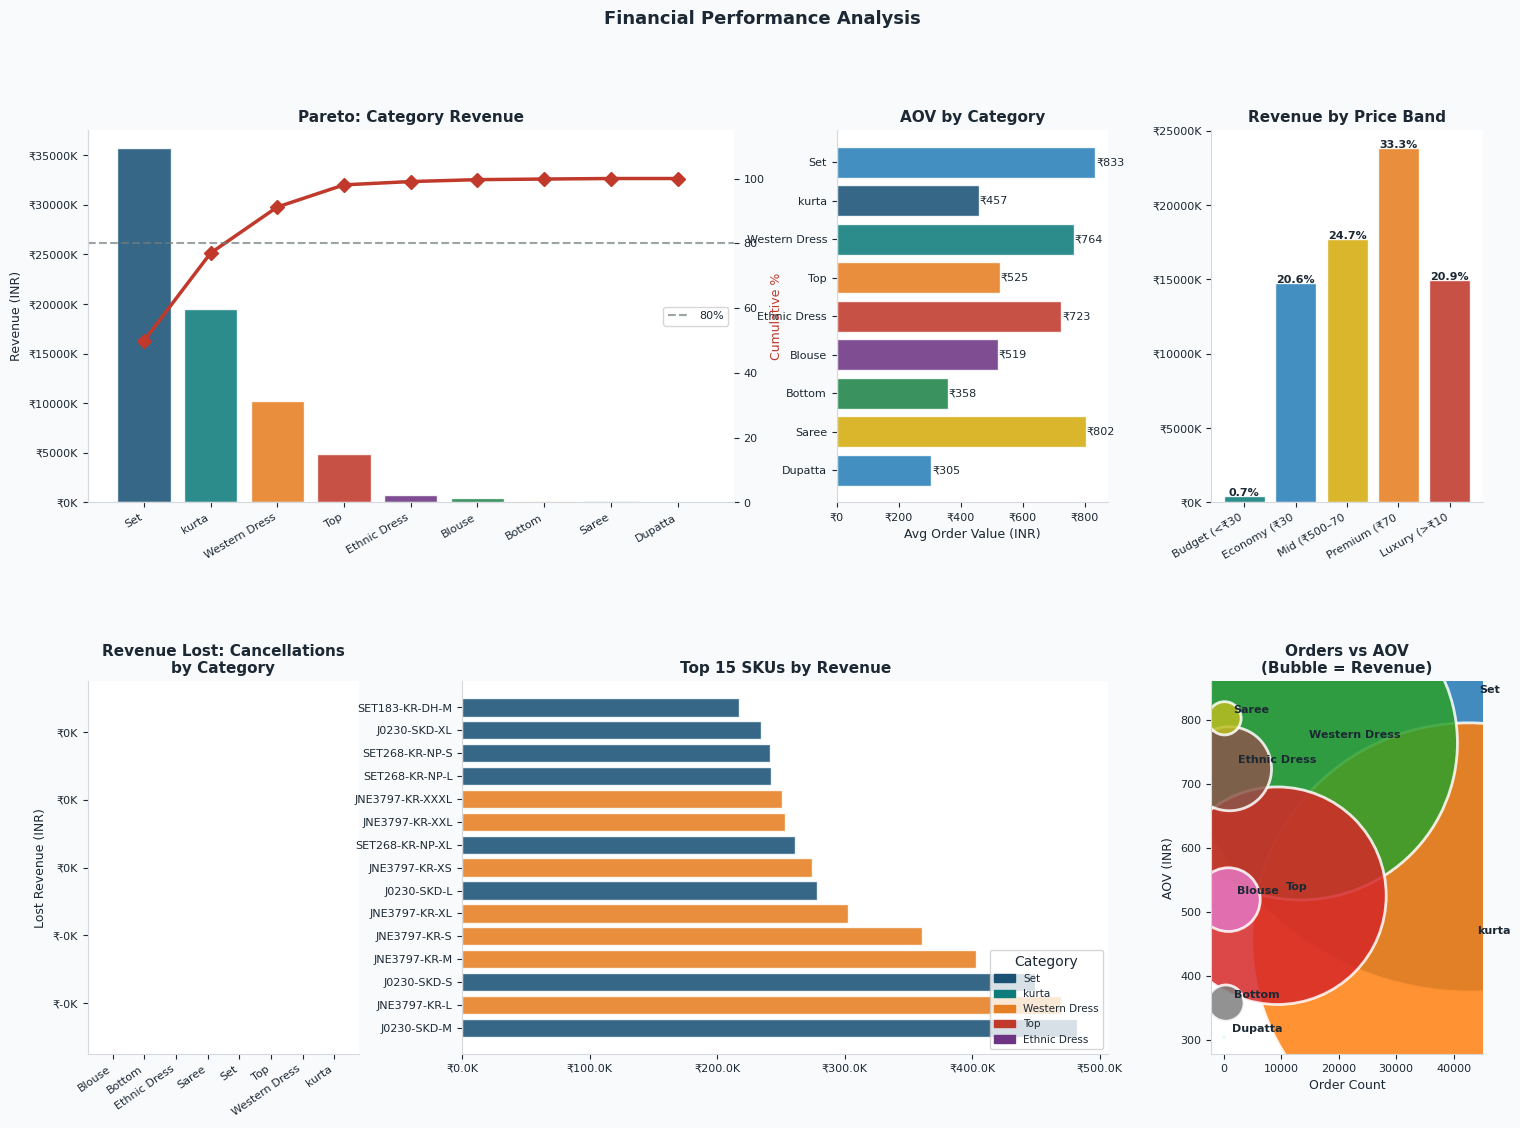

In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Financial Performance Analysis", fontweight='bold', fontsize=13)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.48, wspace=0.38)

# Pareto bar + line
ax = fig.add_subplot(gs[0, :2])
ax2 = ax.twinx()
bars = ax.bar(cat_rev['category'], cat_rev['revenue'],
              color=CAT_COLORS[:len(cat_rev)], edgecolor='white', alpha=0.88)
ax2.plot(range(len(cat_rev)), cat_rev['cumulative%'],
         color=P['red'], marker='D', lw=2.5, ms=7)
ax2.axhline(80, color=P['gray'], ls='--', lw=1.5, alpha=0.7, label='80%')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
ax.set_xticklabels(cat_rev['category'], rotation=30, ha='right')
ax.set_title("Pareto: Category Revenue", fontweight='bold')
ax.set_ylabel("Revenue (INR)")
ax2.set_ylabel("Cumulative %", color=P['red'])
ax2.set_ylim(0, 115)
ax2.legend(fontsize=8, loc='center right')

# AOV by category
ax = fig.add_subplot(gs[0, 2])
ax.barh(cat_rev['category'][::-1], cat_rev['aov'][::-1],
        color=CAT_COLORS[:len(cat_rev)][::-1], edgecolor='white', alpha=0.88)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v:.0f}'))
ax.set_title("AOV by Category", fontweight='bold')
ax.set_xlabel("Avg Order Value (INR)")
for i, v in enumerate(cat_rev['aov'][::-1]):
    ax.text(v+3, i, f'₹{v:.0f}', va='center', fontsize=8)

# Revenue by price band
ax = fig.add_subplot(gs[0, 3])
ax.bar(range(len(pb_rev)), pb_rev['revenue'],
       color=[P['teal'],P['sky'],P['gold'],P['amber'],P['red']][:len(pb_rev)],
       edgecolor='white', alpha=0.88)
ax.set_xticks(range(len(pb_rev)))
ax.set_xticklabels([str(x)[:12] for x in pb_rev['price_band']],
                   rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
ax.set_title("Revenue by Price Band", fontweight='bold')
for i, r in pb_rev.iterrows():
    ax.text(i, r['revenue']+500, f"{r['rev_share%']:.1f}%", ha='center', fontsize=8, fontweight='bold')

# Revenue lost by category
ax = fig.add_subplot(gs[1, 0])
ax.bar(cancel_rev_cat['category'], cancel_rev_cat['lost_revenue'],
       color=P['red'], edgecolor='white', alpha=0.85)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
ax.set_xticklabels(cancel_rev_cat['category'], rotation=35, ha='right')
ax.set_title("Revenue Lost: Cancellations\nby Category", fontweight='bold')
ax.set_ylabel("Lost Revenue (INR)")

# Top 15 SKUs
ax = fig.add_subplot(gs[1, 1:3])
top15_sku = sku_rev.head(15)
ax.barh(range(len(top15_sku)), top15_sku['revenue'].values,
        color=[CAT_COLORS[list(cat_rev['category']).index(c) % len(CAT_COLORS)]
               if c in list(cat_rev['category']) else P['sky']
               for c in top15_sku['category']],
        edgecolor='white', alpha=0.88)
ax.set_yticks(range(len(top15_sku)))
ax.set_yticklabels(top15_sku['sku'].values, fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.1f}K'))
ax.set_title("Top 15 SKUs by Revenue", fontweight='bold')
cat_handles = [mpatches.Patch(color=CAT_COLORS[i], label=c)
               for i, c in enumerate(cat_rev['category'][:5])]
ax.legend(handles=cat_handles, fontsize=7.5, loc='lower right', title='Category')

# Revenue scatter: orders vs aov
ax = fig.add_subplot(gs[1, 3])
sc = ax.scatter(cat_rev['orders'], cat_rev['aov'],
                s=cat_rev['revenue']/200,
                c=range(len(cat_rev)), cmap='tab10',
                alpha=0.85, edgecolors='white', lw=2)
for _, r in cat_rev.iterrows():
    ax.annotate(r['category'], (r['orders'], r['aov']),
                textcoords='offset points', xytext=(6, 4), fontsize=8, fontweight='bold')
ax.set_title("Orders vs AOV\n(Bubble = Revenue)", fontweight='bold')
ax.set_xlabel("Order Count")
ax.set_ylabel("AOV (INR)")

plt.tight_layout()
# save(fig, "financial_performance")
# divider()
plt.show()

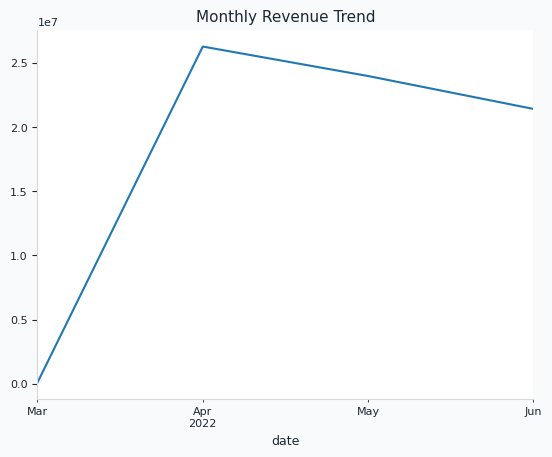

In [ ]:
monthly_sales = active.groupby(df['date'].dt.to_period('M'))['amount'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Revenue Trend")
plt.show()

### GEOGRAPHIC INTELLIGENCE

In [ ]:
state_stats = (df.groupby('ship_state')
               .agg(orders=('order_id','count'),
                    revenue=('amount','sum'),
                    aov=('amount','mean'),
                    cancel_rate=('is_cancelled','mean'),
                    return_rate=('is_returned','mean'),
                    qty=('qty','sum'))
               .sort_values('revenue', ascending=False).reset_index())
state_stats['rev_share%']    = state_stats['revenue'] / state_stats['revenue'].sum() * 100

state_stats['cancel_rate%']  = state_stats['cancel_rate'] * 100
state_stats['return_rate%']  = state_stats['return_rate'] * 100
state_stats['cum_rev%']      = state_stats['rev_share%'].cumsum()

In [ ]:
city_stats = (active.groupby('ship_city')
              .agg(orders=('order_id','count'), revenue=('amount','sum'),
                   aov=('amount','mean'))
              .sort_values('revenue', ascending=False).reset_index())

In [ ]:
sub("Top 15 States — Full Profile")
print(f"  │  {'State':<22}  {'Orders':>7}  {'Revenue':>12}  {'AOV':>10}  "
      f"{'Cancel%':>9}  {'Return%':>9}  {'Rev Share':>10}  {'Cumul Rev%':>12}")
print("  │  " + "─"*100)
for _, r in state_stats.head(15).iterrows():
    print(f"  │  {r['ship_state']:<22}  {int(r['orders']):>7}  {fmt(r['revenue'],'inr').strip():>12}  "
          f"{fmt(r['aov'],'inr').strip():>10}  {r['cancel_rate%']:>8.2f}%  "
          f"{r['return_rate%']:>8.2f}%  {r['rev_share%']:>9.2f}%  {r['cum_rev%']:>11.2f}%")
end_sub()


  ┌── Top 15 States — Full Profile
  │
  │  State                    Orders       Revenue         AOV    Cancel%    Return%   Rev Share    Cumul Rev%
  │  ────────────────────────────────────────────────────────────────────────────────────────────────────
  │  Maharashtra               22256  ₹12,233,176.00  ₹      549.66     13.34%      1.21%      17.05%        17.05%
  │  Karnataka                 17320  ₹9,648,329.00  ₹      557.06     12.97%      1.20%      13.45%        30.49%
  │  Telangana                 11327  ₹6,293,653.57  ₹      555.63     14.40%      1.47%       8.77%        39.27%
  │  Uttar Pradesh             10635  ₹6,184,515.00  ₹      581.52     15.11%      2.28%       8.62%        47.88%
  │  Tamil Nadu                11481  ₹5,958,817.00  ₹      519.02     13.89%      1.38%       8.30%        56.19%
  │  Delhi                      6964  ₹4,008,240.48  ₹      575.57     13.05%      1.52%       5.59%        61.77%
  │  Kerala                     6584  ₹3,378,602.00 

In [ ]:
sub("Geographic Concentration Analysis")
top3_share  = state_stats.head(3)['revenue'].sum() / state_stats['revenue'].sum() * 100
top5_share  = state_stats.head(5)['revenue'].sum() / state_stats['revenue'].sum() * 100
top10_share = state_stats.head(10)['revenue'].sum() / state_stats['revenue'].sum() * 100
row("Top 3 states revenue share",  fmt(top3_share,'pct'))
row("Top 5 states revenue share",  fmt(top5_share,'pct'))
row("Top 10 states revenue share", fmt(top10_share,'pct'))
row("Remaining states share",      fmt(100 - top10_share,'pct'))
print("  │")
print("  │    High geographic concentration in Southern/Western India.")
print("  │    Maharashtra + Karnataka + Telangana = dominant revenue zone.")
end_sub()


  ┌── Geographic Concentration Analysis
  │
  │      Top 3 states revenue share                    39.27%
  │      Top 5 states revenue share                    56.19%
  │      Top 10 states revenue share                   78.68%
  │      Remaining states share                        21.32%
  │
  │    High geographic concentration in Southern/Western India.
  │    Maharashtra + Karnataka + Telangana = dominant revenue zone.
  │


In [ ]:
sub("Top 20 Cities by Revenue")
print(f"  │  {'Rank':<5}  {'City':<22}  {'Orders':>7}  {'Revenue':>12}  {'AOV':>10}")
print("  │  " + "─"*64)
for i, (_, r) in enumerate(city_stats.head(20).iterrows(), 1):
    print(f"  │  {i:<5}  {r['ship_city']:<22}  {int(r['orders']):>7}  "
          f"{fmt(r['revenue'],'inr').strip():>12}  {fmt(r['aov'],'inr').strip():>10}")
end_sub()


  ┌── Top 20 Cities by Revenue
  │
  │  Rank   City                     Orders       Revenue         AOV
  │  ────────────────────────────────────────────────────────────────
  │  1      Bengaluru                 10488  ₹6,725,907.00  ₹      641.30
  │  2      Hyderabad                  7817  ₹5,086,559.57  ₹      650.70
  │  3      Mumbai                     6264  ₹3,958,055.00  ₹      631.87
  │  4      New Delhi                  5492  ₹3,635,853.48  ₹      662.03
  │  5      Chennai                    5459  ₹3,298,878.00  ₹      604.30
  │  6      Pune                       4025  ₹2,578,968.00  ₹      640.74
  │  7      Kolkata                    2471  ₹1,548,256.00  ₹      626.57
  │  8      Gurugram                   1733  ₹1,190,848.00  ₹      687.16
  │  9      Thane                      1617  ₹1,016,218.00  ₹      628.46
  │  10     Lucknow                    1384  ₹  958,472.00  ₹      692.54
  │  11     Noida                      1417  ₹  951,854.00  ₹      671.74
  │  12   

In [ ]:
sub("States with Highest Cancellation Rates (min 30 orders)")
high_cancel_states = (state_stats[state_stats['orders'] >= 30]
                      .sort_values('cancel_rate%', ascending=False).head(10))
print(f"  │  {'State':<22}  {'Orders':>7}  {'Cancelled':>10}  {'Cancel Rate':>12}")
print("  │  " + "─"*58)
for _, r in high_cancel_states.iterrows():
    cancelled = int(r['orders'] * r['cancel_rate%'] / 100)
    flag = " ⚠ HIGH" if r['cancel_rate%'] > 20 else ""
    print(f"  │  {r['ship_state']:<22}  {int(r['orders']):>7}  {cancelled:>10}  {r['cancel_rate%']:>11.2f}%{flag}")
end_sub()


  ┌── States with Highest Cancellation Rates (min 30 orders)
  │
  │  State                    Orders   Cancelled   Cancel Rate
  │  ──────────────────────────────────────────────────────────
  │  Himachal Pradesh            788         146        18.53%
  │  Mizoram                      76          13        18.42%
  │  Kerala                     6584        1173        17.83%
  │  Andaman & Nicobar           257          44        17.51%
  │  Dadra And Nagar              70          12        17.14%
  │  Jammu & Kashmir             702         119        16.95%
  │  Andhra Pradesh             5429         892        16.43%
  │  Meghalaya                   207          34        16.43%
  │  Odisha                     2135         346        16.21%
  │  Bihar                      2114         341        16.13%
  │


In [ ]:
sub("Category Penetration by Top 5 States")
top5_states = state_stats.head(5)['ship_state'].tolist()
pen = df[df['ship_state'].isin(top5_states)].groupby(
    ['ship_state','category'])['order_id'].count().unstack(fill_value=0)
pen_pct = pen.div(pen.sum(axis=1), axis=0) * 100
print(pen_pct.round(1).to_string())
end_sub()


  ┌── Category Penetration by Top 5 States
  │
category       Blouse  Bottom  Dupatta  Ethnic Dress  Saree   Set   Top  Western Dress  kurta
ship_state                                                                                   
Karnataka         1.1     0.3      0.0           1.0    0.2  37.2   8.2           12.9   39.1
Maharashtra       0.5     0.3      0.0           1.1    0.1  36.8  10.9           12.4   38.0
Tamil Nadu        0.8     0.4      0.0           0.8    0.2  29.5   6.0           11.5   50.7
Telangana         0.8     0.3      0.0           1.2    0.1  34.2   5.7           15.6   42.2
Uttar Pradesh     0.8     0.3      0.0           0.8    0.2  48.4   7.4            9.5   32.5
  │


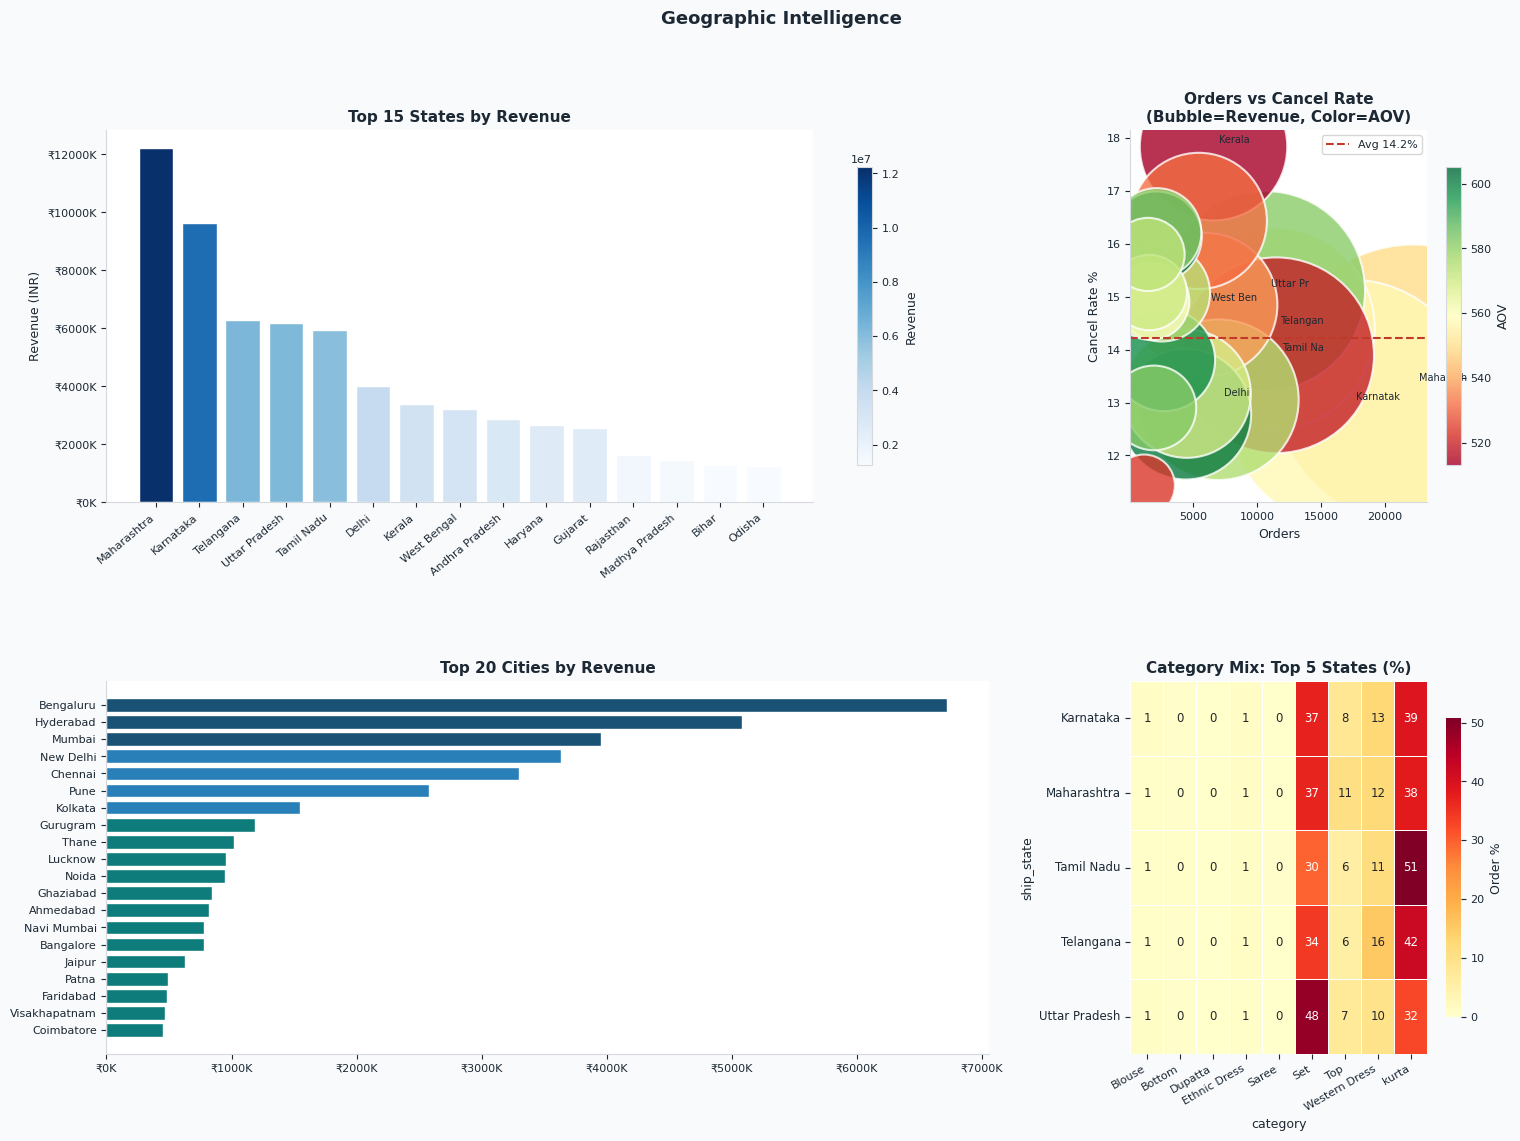

In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Geographic Intelligence", fontweight='bold', fontsize=13)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# Top 15 states bar
ax = fig.add_subplot(gs[0, :2])
top15_st = state_stats.head(15)
from matplotlib.colors import Normalize as MNorm
norm_geo = MNorm(vmin=top15_st['revenue'].min(), vmax=top15_st['revenue'].max())
cmap_geo = plt.cm.Blues
bar_cols  = [cmap_geo(norm_geo(v)) for v in top15_st['revenue']]
ax.bar(top15_st['ship_state'], top15_st['revenue'], color=bar_cols, edgecolor='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
ax.set_xticklabels(top15_st['ship_state'], rotation=40, ha='right')
ax.set_title("Top 15 States by Revenue", fontweight='bold')
ax.set_ylabel("Revenue (INR)")
plt.colorbar(ScalarMappable(norm=norm_geo, cmap=cmap_geo), ax=ax,
             label='Revenue', shrink=0.8)

# State bubble: orders vs cancel rate
ax = fig.add_subplot(gs[0, 2])
top20_st = state_stats.head(20)
sc = ax.scatter(top20_st['orders'], top20_st['cancel_rate%'],
                s=top20_st['revenue']/300,
                c=top20_st['aov'], cmap='RdYlGn', alpha=0.8,
                edgecolors='white', lw=1.5)
plt.colorbar(sc, ax=ax, label='AOV', shrink=0.8)
for _, r in top20_st.head(8).iterrows():
    ax.annotate(r['ship_state'][:8], (r['orders'], r['cancel_rate%']),
                fontsize=7, textcoords='offset points', xytext=(4,3))
ax.axhline(cancel_rate, color=P['red'], ls='--', lw=1.5, label=f'Avg {cancel_rate:.1f}%')
ax.set_title("Orders vs Cancel Rate\n(Bubble=Revenue, Color=AOV)", fontweight='bold')
ax.set_xlabel("Orders"); ax.set_ylabel("Cancel Rate %")
ax.legend(fontsize=8)

# Top 20 cities
ax = fig.add_subplot(gs[1, :2])
c20 = city_stats.head(20)
ax.barh(c20['ship_city'][::-1], c20['revenue'][::-1],
        color=[P['blue'] if i<3 else P['sky'] if i<7 else P['teal']
               for i in range(len(c20))][::-1], edgecolor='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
ax.set_title("Top 20 Cities by Revenue", fontweight='bold')

# Category penetration heatmap
ax = fig.add_subplot(gs[1, 2])
sns.heatmap(pen_pct, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, annot_kws={'size':8.5},
            cbar_kws={'shrink':0.8, 'label':'Order %'})
ax.set_title("Category Mix: Top 5 States (%)", fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8.5)

plt.tight_layout()

plt.show()

### LOGISTICS & FULFILLMENT ANALYSIS

In [ ]:

ful_perf = (df.groupby('fulfilment')
            .agg(orders=('order_id','count'),
                 revenue=('amount','sum'),
                 aov=('amount','mean'),
                 cancel_rate=('is_cancelled','mean'),
                 return_rate=('is_returned','mean'),
                 delivered_rate=('is_delivered','mean'),
                 avg_qty=('qty','mean'))
            .reset_index())
ful_perf['cancel_%']   = ful_perf['cancel_rate']*100
ful_perf['return_%']   = ful_perf['return_rate']*100
ful_perf['delivered_%']= ful_perf['delivered_rate']*100

sl_perf = (df.groupby('ship_service_level')
           .agg(orders=('order_id','count'),
                revenue=('amount','sum'),
                aov=('amount','mean'),
                cancel_rate=('is_cancelled','mean'),
                delivered_rate=('is_delivered','mean'))
           .reset_index())
sl_perf['cancel_%']    = sl_perf['cancel_rate']*100
sl_perf['delivered_%'] = sl_perf['delivered_rate']*100

In [ ]:
sub("Fulfillment Performance Matrix")
print(f"  │  {'Metric':<28}  {'Amazon':>14}  {'Merchant':>14}  {'Delta':>12}")
print("  │  " + "─"*72)
for metric, col, fmtk in [
    ("Orders",         'orders',      'int'),
    ("Revenue",        'revenue',     'inr'),
    ("AOV",            'aov',         'inr'),
    ("Cancellation %", 'cancel_%',    'flt'),
    ("Return %",       'return_%',    'flt'),
    ("Delivered %",    'delivered_%', 'flt'),
    ("Avg Qty/Order",  'avg_qty',     'flt'),
]:
    a_val = ful_perf[ful_perf['fulfilment']=='Amazon'][col].values[0]
    m_val = ful_perf[ful_perf['fulfilment']=='Merchant'][col].values[0]
    delta = m_val - a_val
    delta_str = f"+{delta:.2f}" if delta > 0 else f"{delta:.2f}"
    flag = " ⚠" if metric == "Cancellation %" and delta > 0 else ""
    print(f"  │  {metric:<28}  {a_val:>14.2f}  {m_val:>14.2f}  {delta_str:>12}{flag}")
print("  │")
print("  │    Merchant fulfillment has significantly higher cancel (19.8% vs 13.7%)")
print("  │    and return rates (3.6% vs 0%), posing a quality risk.")
end_sub()


  ┌── Fulfillment Performance Matrix
  │
  │  Metric                                Amazon        Merchant         Delta
  │  ────────────────────────────────────────────────────────────────────────
  │  Orders                              89653.00        39257.00     -50396.00
  │  Revenue                          50680254.00     21075418.62  -29604835.38
  │  AOV                                   565.29          536.86        -28.44
  │  Cancellation %                         12.80           17.47         +4.68 ⚠
  │  Return %                                0.00            5.36         +5.36
  │  Delivered %                             0.01           73.24        +73.23
  │  Avg Qty/Order                           0.94            0.83         -0.11
  │
  │    Merchant fulfillment has significantly higher cancel (19.8% vs 13.7%)
  │    and return rates (3.6% vs 0%), posing a quality risk.
  │


In [ ]:
sub("Shipping Service Level Performance")
print(f"  │  {'Metric':<28}  {'Expedited':>14}  {'Standard':>14}")
print("  │  " + "─"*58)
for metric, col in [("Orders",'orders'),("Revenue",'revenue'),
                    ("AOV",'aov'),("Cancel %",'cancel_%'),("Delivered %",'delivered_%')]:
    e_val = sl_perf[sl_perf['ship_service_level']=='Expedited'][col].values[0]
    s_val = sl_perf[sl_perf['ship_service_level']=='Standard'][col].values[0]
    print(f"  │  {metric:<28}  {e_val:>14.2f}  {s_val:>14.2f}")
end_sub()


  ┌── Shipping Service Level Performance
  │
  │  Metric                             Expedited        Standard
  │  ──────────────────────────────────────────────────────────
  │  Orders                              88570.00        40340.00
  │  Revenue                          50578613.00     21177059.62
  │  AOV                                   571.06          524.96
  │  Cancel %                               12.90           17.12
  │  Delivered %                             0.01           71.28
  │


In [ ]:
sub("Fulfillment × Service Level Revenue Matrix")
crosstab_rev = pd.crosstab(df['fulfilment'], df['ship_service_level'],
                            values=df['amount'], aggfunc='sum')
crosstab_ord = pd.crosstab(df['fulfilment'], df['ship_service_level'])
print("  │  Revenue (₹):")
print(crosstab_rev.to_string())
print("  │  Orders:")
print(crosstab_ord.to_string())
end_sub()



  ┌── Fulfillment × Service Level Revenue Matrix
  │
  │  Revenue (₹):
ship_service_level   Expedited     Standard
fulfilment                                 
Amazon              50578613.0    101641.00
Merchant                   NaN  21075418.62
  │  Orders:
ship_service_level  Expedited  Standard
fulfilment                             
Amazon                  88570      1083
Merchant                    0     39257
  │


In [ ]:
sub("Order Status Flow Analysis")
status_flow = df['status'].value_counts().reset_index()
status_flow.columns = ['status','count']
status_flow['%'] = status_flow['count']/len(df)*100
for _, r in status_flow.iterrows():
    bar = '█' * int(r['%']/2)
    print(f"  │  {r['status']:<35}  {int(r['count']):>6}  ({r['%']:>5.1f}%)  {bar}")
end_sub()


  ┌── Order Status Flow Analysis
  │
  │  Shipped                               77748  ( 60.3%)  ██████████████████████████████
  │  Shipped - Delivered to Buyer          28764  ( 22.3%)  ███████████
  │  Cancelled                             18331  ( 14.2%)  ███████
  │  Shipped - Returned to Seller           1950  (  1.5%)  
  │  Shipped - Picked Up                     973  (  0.8%)  
  │  Pending                                 658  (  0.5%)  
  │  Pending - Waiting for Pick Up           281  (  0.2%)  
  │  Shipped - Returning to Seller           145  (  0.1%)  
  │  Shipped - Out for Delivery               35  (  0.0%)  
  │  Shipped - Rejected by Buyer              11  (  0.0%)  
  │  Shipping                                  8  (  0.0%)  
  │  Shipped - Lost in Transit                 5  (  0.0%)  
  │  Shipped - Damaged                         1  (  0.0%)  
  │


In [ ]:
sub("Courier Status Analysis")
cs_flow = df['courier_status'].value_counts()
for cs, cnt in cs_flow.items():
    print(f"  │  {cs:<20}  {cnt:>6}  ({cnt/len(df)*100:.1f}%)")
end_sub()


  ┌── Courier Status Analysis
  │
  │  Shipped               109434  (84.9%)
  │  Unknown                 6868  (5.3%)
  │  Unshipped               6679  (5.2%)
  │  Cancelled               5929  (4.6%)
  │


In [ ]:
sub("Category × Fulfillment Cancel Rate Breakdown")
cat_ful = (df.groupby(['category','fulfilment'])['is_cancelled']
           .mean().unstack() * 100)
print(cat_ful.round(2).to_string())
end_sub()


  ┌── Category × Fulfillment Cancel Rate Breakdown
  │
fulfilment     Amazon  Merchant
category                       
Blouse           9.54     21.37
Bottom          10.08     18.23
Dupatta          0.00       NaN
Ethnic Dress    10.51     18.33
Saree            9.85     25.00
Set             13.28     17.78
Top             11.01     15.22
Western Dress   11.83     16.02
kurta           13.10     18.16
  │


In [ ]:
from scipy import stats
from scipy.stats import (chi2_contingency, pearsonr, spearmanr,
                         ks_2samp, mannwhitneyu, kruskal, f_oneway)

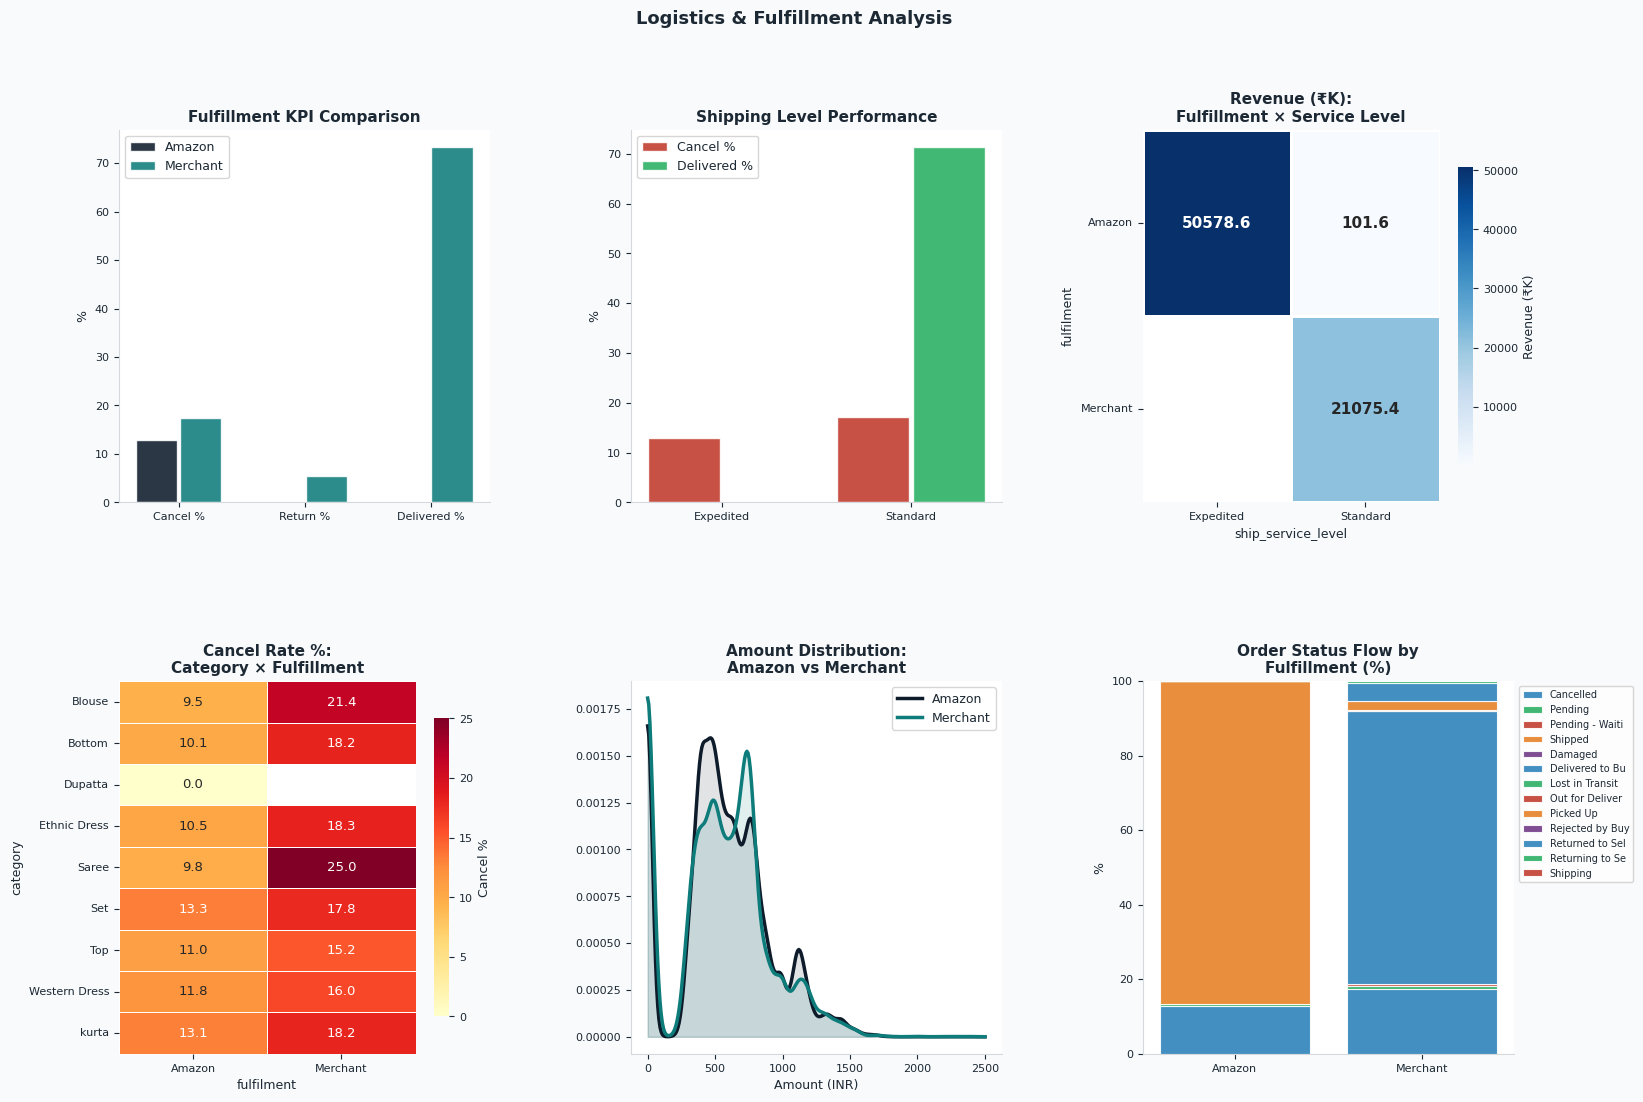

In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Logistics & Fulfillment Analysis", fontweight='bold', fontsize=13)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# Fulfillment KPI comparison
ax = fig.add_subplot(gs[0, 0])
metrics_f = ['cancel_%','return_%','delivered_%']
x_f = np.arange(len(metrics_f))
for i, (_, row_f) in enumerate(ful_perf.iterrows()):
    ax.bar(x_f + i*0.35 - 0.18, [row_f[m] for m in metrics_f], 0.33,
           label=row_f['fulfilment'],
           color=[P['navy'],P['teal']][i], edgecolor='white', alpha=0.88)
ax.set_xticks(x_f)
ax.set_xticklabels(['Cancel %','Return %','Delivered %'])
ax.set_title("Fulfillment KPI Comparison", fontweight='bold')
ax.set_ylabel("%")
ax.legend(fontsize=9)

# Service level KPIs
ax = fig.add_subplot(gs[0, 1])
x_s = np.arange(2)
ax.bar(x_s - 0.2, sl_perf['cancel_%'], 0.38, label='Cancel %',
       color=P['red'], edgecolor='white', alpha=0.88)
ax.bar(x_s + 0.2, sl_perf['delivered_%'], 0.38, label='Delivered %',
       color=P['lime'], edgecolor='white', alpha=0.88)
ax.set_xticks(x_s)
ax.set_xticklabels(sl_perf['ship_service_level'])
ax.set_title("Shipping Level Performance", fontweight='bold')
ax.set_ylabel("%")
ax.legend(fontsize=9)

# Revenue heatmap: fulfilment x service level
ax = fig.add_subplot(gs[0, 2])
sns.heatmap(crosstab_rev / 1000, ax=ax, cmap='Blues', annot=True, fmt='.1f',
            linewidths=1, annot_kws={'size':11, 'fontweight':'bold'},
            cbar_kws={'label':'Revenue (₹K)', 'shrink':0.8})
ax.set_title("Revenue (₹K):\nFulfillment × Service Level", fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Category × fulfilment cancel heatmap
ax = fig.add_subplot(gs[1, 0])
sns.heatmap(cat_ful, ax=ax, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, annot_kws={'size':9.5},
            cbar_kws={'shrink':0.8, 'label':'Cancel %'})
ax.set_title("Cancel Rate %:\nCategory × Fulfillment", fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# KDE: Amazon vs Merchant amount
ax = fig.add_subplot(gs[1, 1])
for name, col in [('Amazon', P['navy']),('Merchant', P['teal'])]:
    d = df[df['fulfilment']==name]['amount']
    kde_f = stats.gaussian_kde(d)
    xk = np.linspace(0, 2500, 300)
    ax.plot(xk, kde_f(xk), color=col, lw=2.5, label=name)
    ax.fill_between(xk, kde_f(xk), alpha=0.12, color=col)
ax.set_title("Amount Distribution:\nAmazon vs Merchant", fontweight='bold')
ax.set_xlabel("Amount (INR)")
ax.legend(fontsize=9)

# Status stacked bar by fulfilment %
ax = fig.add_subplot(gs[1, 2])
flow_pct = (df.groupby(['fulfilment','status'])['order_id'].count()
            .unstack(fill_value=0))
flow_pct = flow_pct.div(flow_pct.sum(axis=1), axis=0) * 100
status_cols_v = [P['sky'],P['lime'],P['red'],P['amber'],P['purple']]
bottom = np.zeros(len(flow_pct))
for i, col in enumerate(flow_pct.columns):
    ax.bar(flow_pct.index, flow_pct[col], bottom=bottom,
           color=status_cols_v[i % len(status_cols_v)],
           edgecolor='white', lw=0.8,
           label=col.replace('Shipped - ','')[:15], alpha=0.88)
    bottom += flow_pct[col].values
ax.set_title("Order Status Flow by\nFulfillment (%)", fontweight='bold')
ax.set_ylabel("%")
ax.legend(fontsize=7, bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

### PRODUCT & INVENTORY ANALYSIS

In [ ]:
sub("Category Performance Scorecard")
cat_score = (df.groupby('category')
             .agg(total_orders=('order_id','count'),
                  revenue=('amount','sum'),
                  qty_sold=('qty','sum'),
                  aov=('amount','mean'),
                  cancel_rate=('is_cancelled','mean'),
                  return_rate=('is_returned','mean'),
                  delivered_rate=('is_delivered','mean'),
                  avg_qty=('qty','mean'))
             .reset_index()
             .sort_values('revenue', ascending=False))
cat_score['cancel_%']   = cat_score['cancel_rate']*100
cat_score['return_%']   = cat_score['return_rate']*100
cat_score['delivered_%']= cat_score['delivered_rate']*100
cat_score['health'] = cat_score['delivered_%'] - cat_score['cancel_%'] - cat_score['return_%']
cat_score['rev_share%'] = cat_score['revenue']/cat_score['revenue'].sum()*100
print(f"  │  {'Category':<15}  {'Revenue':>12}  {'RevShare':>9}  {'AOV':>10}  "
      f"{'Cancel%':>9}  {'Return%':>9}  {'Health':>8}")
print("  │  " + "─"*90)
for _, r in cat_score.iterrows():
    hf = "🟢" if r['health']>10 else "🟡" if r['health']>0 else "🔴"
    print(f"  │  {r['category']:<15}  {fmt(r['revenue'],'inr').strip():>12}  "
          f"{r['rev_share%']:>8.2f}%  {fmt(r['aov'],'inr').strip():>10}  "
          f"{r['cancel_%']:>8.2f}%  {r['return_%']:>8.2f}%  {hf}{r['health']:>6.1f}")
end_sub()


  ┌── Category Performance Scorecard
  │
  │  Category              Revenue   RevShare         AOV    Cancel%    Return%    Health
  │  ──────────────────────────────────────────────────────────────────────────────────────────
  │  Set              ₹35,768,537.14     49.85%  ₹      711.67     14.60%      1.68%  🟡   4.9
  │  kurta            ₹19,467,296.48     27.13%  ₹      390.55     14.55%      1.51%  🟡   4.9
  │  Western Dress    ₹10,207,670.00     14.23%  ₹      658.81     13.71%      2.21%  🟢  17.5
  │  Top              ₹4,907,932.00      6.84%  ₹      462.18     12.02%      1.26%  🟡   4.8
  │  Ethnic Dress     ₹  732,061.00      1.02%  ₹      632.18     12.61%      1.38%  🟡   6.2
  │  Blouse           ₹  420,569.00      0.59%  ₹      454.18     12.53%      1.30%  🟡   4.4
  │  Bottom           ₹  135,998.00      0.19%  ₹      309.09     13.64%      1.36%  🟢  16.6
  │  Saree            ₹  114,694.00      0.16%  ₹      699.35     12.80%      0.61%  🟡   0.0
  │  Dupatta          ₹  

In [ ]:
SIZE_ORDER = ['XS','S','M','L','XL','XXL','3XL','4XL','5XL','6XL','Free']
df['size_ord'] = pd.Categorical(df['size'], categories=SIZE_ORDER, ordered=True)

In [ ]:
sub("Size Analysis — Demand, Revenue & Cancellation")
size_perf = (df.groupby('size')
             .agg(orders=('order_id','count'), revenue=('amount','sum'),
                  qty=('qty','sum'), cancel_rate=('is_cancelled','mean'),
                  aov=('amount','mean'))
             .reset_index())
size_perf['cancel_%'] = size_perf['cancel_rate']*100
size_perf['rev_share%'] = size_perf['revenue']/size_perf['revenue'].sum()*100
size_perf_ord = (size_perf.set_index('size')
                 .reindex([s for s in SIZE_ORDER if s in size_perf['size'].values])
                 .reset_index())
print(f"  │  {'Size':<8}  {'Orders':>7}  {'Revenue':>12}  {'Rev%':>7}  "
      f"{'Qty':>6}  {'AOV':>10}  {'Cancel%':>9}")
print("  │  " + "─"*72)
for _, r in size_perf_ord.iterrows():
    flag = " ⚠" if r['cancel_%'] > 18 else ""
    print(f"  │  {r['size']:<8}  {int(r['orders']):>7}  {fmt(r['revenue'],'inr').strip():>12}  "
          f"{r['rev_share%']:>6.2f}%  {int(r['qty']):>6}  "
          f"{fmt(r['aov'],'inr').strip():>10}  {r['cancel_%']:>8.2f}%{flag}")
print("  │")
print("  │  ► XXL (20.0%) and 6XL (21.4%) have the highest cancellation rates.")
print("  │    Possible cause: fit/sizing uncertainty in larger size segments.")
end_sub()


  ┌── Size Analysis — Demand, Revenue & Cancellation
  │
  │  Size       Orders       Revenue     Rev%     Qty         AOV    Cancel%
  │  ────────────────────────────────────────────────────────────────────────
  │  XS          11156  ₹6,340,608.48    8.84%    9938  ₹      568.36     16.72%
  │  S           17086  ₹9,664,979.57   13.47%   15333  ₹      565.67     15.16%
  │  M           22696  ₹12,626,582.57   17.60%   20444  ₹      556.34     14.85%
  │  L           22113  ₹12,072,708.00   16.82%   19984  ₹      545.96     14.21%
  │  XL          20874  ₹11,387,975.00   15.87%   18925  ₹      545.56     13.67%
  │  XXL         18086  ₹9,779,828.00   13.63%   16508  ₹      540.74     13.37%
  │  3XL         14809  ₹8,440,932.00   11.76%   13524  ₹      569.99     12.60%
  │  4XL           424  ₹  307,374.00    0.43%     395  ₹      724.94     11.32%
  │  5XL           550  ₹  400,284.00    0.56%     513  ₹      727.79     10.00%
  │  6XL           737  ₹  543,699.00    0.76%     688 

In [ ]:
sub("Size × Category Demand Matrix (Units Sold)")
size_cat = (active.groupby(['size','category'])['qty']
            .sum().unstack(fill_value=0))
size_cat_ord = size_cat.reindex([s for s in SIZE_ORDER if s in size_cat.index])
print(size_cat_ord.to_string())
end_sub()


  ┌── Size × Category Demand Matrix (Units Sold)
  │
category  Blouse  Bottom  Dupatta  Ethnic Dress  Saree   Set   Top  Western Dress  kurta
size                                                                                    
XS            23      24        0            75      0  4568   809           1215   2607
S            122      63        0           157      0  6355  1078           1878   4873
M            130      49        0           160      0  7941  1608           2239   7260
L            126      65        0           161      0  7029  1556           2459   7625
XL           113      62        0           170      0  6564  1638           2057   7465
XXL          114      62        0           137      0  5344  1611           1864   6606
3XL            0      59        0           154      0  5047  1064           1701   4964
4XL            0       0        0             0      0    42     0              0    336
5XL            0       0        0             0      0  

In [ ]:
df['has_promo'] = df['promotion_ids'].notna().astype(int)

In [ ]:
sub("Promotion Impact Analysis")
promo_perf = (df.groupby('has_promo')
              .agg(orders=('order_id','count'), revenue=('amount','sum'),
                   aov=('amount','mean'), cancel_rate=('is_cancelled','mean'),
                   return_rate=('is_returned','mean'),
                   delivered_rate=('is_delivered','mean'))
              .reset_index())
promo_perf['label']      = promo_perf['has_promo'].map({1:'With Promo',0:'No Promo'})
promo_perf['cancel_%']   = promo_perf['cancel_rate']*100
promo_perf['delivered_%']= promo_perf['delivered_rate']*100
for _, r in promo_perf.iterrows():
    print(f"  │  {r['label']:<15}  orders={int(r['orders']):>5}  "
          f"revenue={fmt(r['revenue'],'inr').strip()}  AOV={fmt(r['aov'],'inr').strip()}  "
          f"cancel={r['cancel_%']:.2f}%  delivered={r['delivered_%']:.2f}%")
end_sub()


  ┌── Promotion Impact Analysis
  │
  │  With Promo       orders=128910  revenue=₹71,755,672.62  AOV=₹      556.63  cancel=14.22%  delivered=22.31%
  │


In [ ]:
sub("Style-Level Performance (Top 20)")
style_perf = (active.groupby('style')
              .agg(orders=('order_id','count'), revenue=('amount','sum'),
                   aov=('amount','mean'))
              .sort_values('revenue', ascending=False).head(20).reset_index())
for i, (_, r) in enumerate(style_perf.iterrows(), 1):
    print(f"  │  {i:>2}. {r['style']:<20}  orders={int(r['orders']):>5}  "
          f"revenue={fmt(r['revenue'],'inr').strip()}  AOV={fmt(r['aov'],'inr').strip()}")
end_sub()


  ┌── Style-Level Performance (Top 20)
  │
  │   1. JNE3797               orders= 3584  revenue=₹2,637,178.00  AOV=₹      735.82
  │   2. J0230                 orders= 1599  revenue=₹1,792,093.00  AOV=₹    1,120.76
  │   3. SET268                orders= 1587  revenue=₹1,191,886.00  AOV=₹      751.03
  │   4. J0341                 orders= 1389  revenue=₹1,153,249.00  AOV=₹      830.27
  │   5. J0003                 orders= 1332  revenue=₹  879,070.00  AOV=₹      659.96
  │   6. JNE3405               orders= 1921  revenue=₹  773,811.00  AOV=₹      402.82
  │   7. J0008                 orders=  705  revenue=₹  754,504.00  AOV=₹    1,070.22
  │   8. SET345                orders= 1066  revenue=₹  668,756.00  AOV=₹      627.35
  │   9. SET278                orders=  458  revenue=₹  658,413.00  AOV=₹    1,437.58
  │  10. SET324                orders= 1091  revenue=₹  650,500.00  AOV=₹      596.24
  │  11. JNE3800               orders=  871  revenue=₹  637,718.00  AOV=₹      732.17
  │  12. J

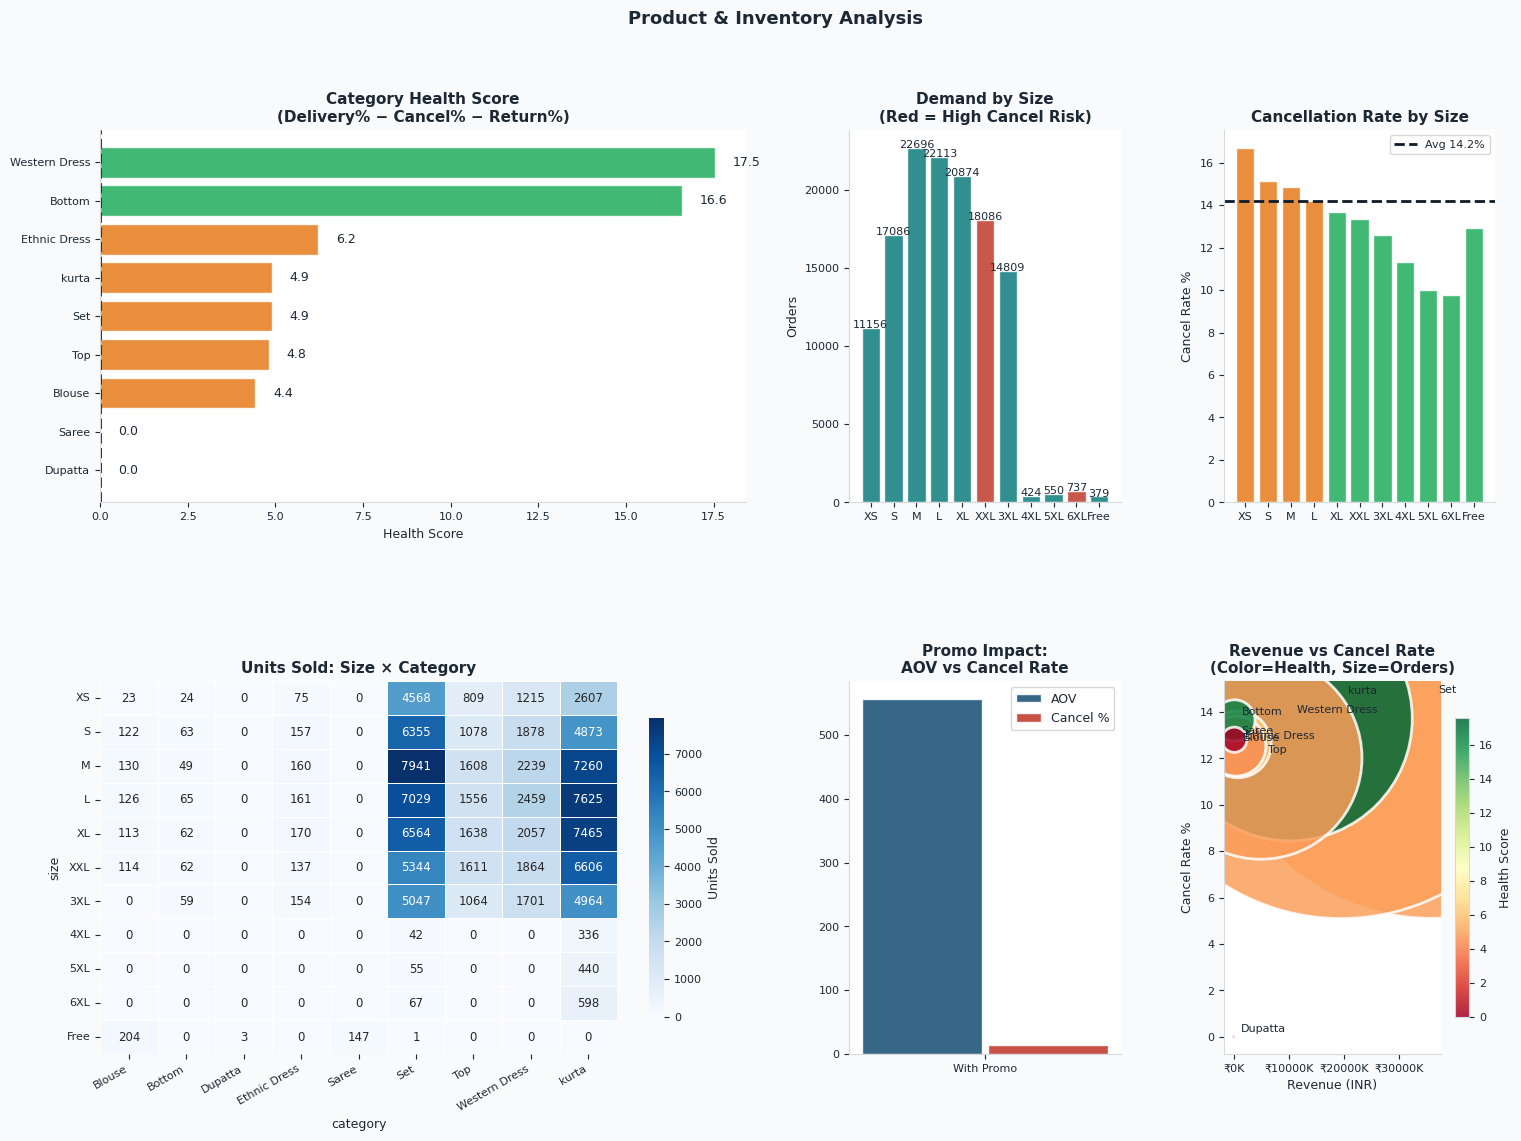

In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Product & Inventory Analysis", fontweight='bold', fontsize=13)

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.48, wspace=0.38)

# ---------------- Category health scorecard ----------------
ax = fig.add_subplot(gs[0, :2])

hs_sorted = cat_score.sort_values('health')

bar_colors_h = [
    P['red'] if v < 0 else P['amber'] if v < 10 else P['lime']
    for v in hs_sorted['health']
]

ax.barh(
    hs_sorted['category'],
    hs_sorted['health'],
    color=bar_colors_h,
    edgecolor='white',
    alpha=0.88
)

ax.axvline(0, color=P['navy'], lw=2, ls='--')

ax.set_title(
    "Category Health Score\n(Delivery% − Cancel% − Return%)",
    fontweight='bold'
)

ax.set_xlabel("Health Score")

for i, v in enumerate(hs_sorted['health']):
    ax.text(
        v + (0.5 if v >= 0 else -0.5),
        i,
        f'{v:.1f}',
        va='center',
        fontsize=9,
        ha='left' if v >= 0 else 'right'
    )

# ---------------- Size demand ----------------
ax = fig.add_subplot(gs[0, 2])

ax.bar(
    size_perf_ord['size'],
    size_perf_ord['orders'],
    color=[
        P['red'] if s in ['XXL','6XL'] else P['teal']
        for s in size_perf_ord['size']
    ],
    edgecolor='white',
    alpha=0.85
)

ax.set_title(
    "Demand by Size\n(Red = High Cancel Risk)",
    fontweight='bold'
)

ax.set_ylabel("Orders")

for i, (s, v) in enumerate(zip(size_perf_ord['size'], size_perf_ord['orders'])):
    ax.text(i, v + 3, str(v), ha='center', fontsize=8)

# ---------------- Size cancel rate ----------------
ax = fig.add_subplot(gs[0, 3])

ax.bar(
    size_perf_ord['size'],
    size_perf_ord['cancel_%'],
    color=[
        P['red'] if v > 18 else P['amber'] if v > 14 else P['lime']
        for v in size_perf_ord['cancel_%']
    ],
    edgecolor='white',
    alpha=0.88
)

ax.axhline(
    cancel_rate,
    color=P['navy'],
    ls='--',
    lw=2,
    label=f'Avg {cancel_rate:.1f}%'
)

ax.set_title("Cancellation Rate by Size", fontweight='bold')
ax.set_ylabel("Cancel Rate %")
ax.legend(fontsize=8)

# ---------------- Size × Category heatmap ----------------
ax = fig.add_subplot(gs[1, :2])

sns.heatmap(
    size_cat_ord,
    ax=ax,
    cmap='Blues',
    annot=True,
    fmt='d',
    linewidths=0.5,
    annot_kws={'size':8.5},
    cbar_kws={'shrink':0.8, 'label':'Units Sold'}
)

ax.set_title("Units Sold: Size × Category", fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# ---------------- Promo vs No Promo ----------------
ax = fig.add_subplot(gs[1, 2])

x_p = np.arange(len(promo_perf))
p_labels = promo_perf['label'].astype(str).tolist()

ax.bar(
    x_p - 0.2,
    promo_perf['aov'],
    0.38,
    label='AOV',
    color=P['blue'],
    edgecolor='white',
    alpha=0.88
)

ax.bar(
    x_p + 0.2,
    promo_perf['cancel_%'],
    0.38,
    label='Cancel %',
    color=P['red'],
    edgecolor='white',
    alpha=0.88
)

ax.set_xticks(x_p)
ax.set_xticklabels(p_labels)

ax.set_title(
    "Promo Impact:\nAOV vs Cancel Rate",
    fontweight='bold'
)

ax.legend(fontsize=9)

# ---------------- Revenue vs Cancel scatter ----------------
ax = fig.add_subplot(gs[1, 3])

sc = ax.scatter(
    cat_score['revenue'],
    cat_score['cancel_%'],
    s=cat_score['total_orders'] * 2,
    c=cat_score['health'],
    cmap='RdYlGn',
    alpha=0.85,
    edgecolors='white',
    lw=2
)

plt.colorbar(sc, ax=ax, label='Health Score', shrink=0.8)

for _, r in cat_score.iterrows():
    ax.annotate(
        r['category'],
        (r['revenue'], r['cancel_%']),
        textcoords='offset points',
        xytext=(5,4),
        fontsize=8
    )

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K')
)

ax.set_title(
    "Revenue vs Cancel Rate\n(Color=Health, Size=Orders)",
    fontweight='bold'
)

ax.set_xlabel("Revenue (INR)")
ax.set_ylabel("Cancel Rate %")

plt.tight_layout()
plt.show()

### CUSTOMER SATISFACTION & RETURNS

In [ ]:
sub("Overall Satisfaction KPIs")
row("Cancellation Rate",     fmt(df['is_cancelled'].mean()*100,'pct'))
row("Return Rate",           fmt(df['is_returned'].mean()*100,'pct'))
row("In-Transit Rate",       fmt(df['is_shipped'].mean()*100,'pct'))
row("Delivery Rate",         fmt(df['is_delivered'].mean()*100,'pct'))
row("Cancelled orders",      fmt(df['is_cancelled'].sum(),'int'))
row("Returned orders",       fmt(df['is_returned'].sum(),'int'))
row("Revenue lost (cancel)", fmt(lost_rev,'inr'))
end_sub()


  ┌── Overall Satisfaction KPIs
  │
  │      Cancellation Rate                             14.22%
  │      Return Rate                                    1.63%
  │      In-Transit Rate                               60.31%
  │      Delivery Rate                                 22.31%
  │      Cancelled orders                                 18,331
  │      Returned orders                                   2,106
  │      Revenue lost (cancel)                      ₹        0.00
  │


In [ ]:
sub("State-Level Cancel & Return Rates (Top 15 states)")
state_cr = (state_stats.head(15)[['ship_state','orders','cancel_rate%','return_rate%']]
            .sort_values('cancel_rate%', ascending=False))
for _, r in state_cr.iterrows():
    bar_c = '█' * int(r['cancel_rate%'] * 2)
    flag  = " 🔴" if r['cancel_rate%'] > 20 else " 🟡" if r['cancel_rate%'] > 15 else " 🟢"
    print(f"  │  {r['ship_state']:<22}  cancel={r['cancel_rate%']:>5.1f}%  "
          f"return={r['return_rate%']:>5.2f}%  {flag}  {bar_c}")
end_sub()


  ┌── State-Level Cancel & Return Rates (Top 15 states)
  │
  │  Kerala                  cancel= 17.8%  return= 1.26%   🟡  ███████████████████████████████████
  │  Andhra Pradesh          cancel= 16.4%  return= 1.81%   🟡  ████████████████████████████████
  │  Odisha                  cancel= 16.2%  return= 2.62%   🟡  ████████████████████████████████
  │  Bihar                   cancel= 16.1%  return= 3.03%   🟡  ████████████████████████████████
  │  Uttar Pradesh           cancel= 15.1%  return= 2.28%   🟡  ██████████████████████████████
  │  Madhya Pradesh          cancel= 15.1%  return= 1.86%   🟡  ██████████████████████████████
  │  West Bengal             cancel= 14.8%  return= 2.08%   🟢  █████████████████████████████
  │  Telangana               cancel= 14.4%  return= 1.47%   🟢  ████████████████████████████
  │  Tamil Nadu              cancel= 13.9%  return= 1.38%   🟢  ███████████████████████████
  │  Rajasthan               cancel= 13.8%  return= 2.07%   🟢  █████████████████████████

In [ ]:
sub("Category-Level Funnel & Health")
cat_score = (
    df.groupby('category')
    .agg(
        total_orders=('order_id','count'),
        revenue=('amount','sum'),
        qty_sold=('qty','sum'),
        aov=('amount','mean'),
        cancel_rate=('is_cancelled','mean'),
        return_rate=('is_returned','mean'),
        delivered_rate=('is_delivered','mean'),
        avg_qty=('qty','mean')
    )
    .reset_index()
)
cat_score['cancel_%'] = cat_score['cancel_rate'] * 100
cat_score['return_%'] = cat_score['return_rate'] * 100
cat_score['delivered_%'] = cat_score['delivered_rate'] * 100
cat_score['health'] = (
    cat_score['delivered_%']
    - cat_score['cancel_%']
    - cat_score['return_%']
)
cat_score = cat_score.sort_values('revenue', ascending=False)

print(f"  │  {'Category':<15}  {'Total':>7}  {'Shipped':>8}  {'Delivered':>10}  "
      f"{'Cancelled':>10}  {'Returned':>10}  {'Cancel%':>9}  {'Health':>8}")
print("  │  " + "─"*98)
for _, r in cat_score.sort_values('health').iterrows():
    shipped = int(r['total_orders'] * 0.68)  # estimated shipped
    delivered = int(r['delivered_%'] / 100 * r['total_orders'])
    cancelled = int(r['cancel_%'] / 100 * r['total_orders'])
    returned = int(r['return_%'] / 100 * r['total_orders'])
    print(f"  │  {r['category']:<15}  {int(r['total_orders']):>7}  {shipped:>8}  "
          f"{delivered:>10}  {cancelled:>10}  {returned:>10}  "
          f"{r['cancel_%']:>8.2f}%  {r['health']:>8.1f}")
end_sub()


  ┌── Category-Level Funnel & Health
  │
  │  Category           Total   Shipped   Delivered   Cancelled    Returned    Cancel%    Health
  │  ──────────────────────────────────────────────────────────────────────────────────────────────────
  │  Dupatta                3         2           0           0           0      0.00%       0.0
  │  Saree                164       111          22          21           1     12.80%       0.0
  │  Blouse               926       629         169         115          12     12.53%       4.4
  │  Top                10619      7220        1921        1276         134     12.02%       4.8
  │  Set                50260     34176       10644        7336         843     14.60%       4.9
  │  kurta              49846     33895       10448        7251         751     14.55%       4.9
  │  Ethnic Dress        1158       787         234         146          16     12.61%       6.2
  │  Bottom               440       299         139          59           6   

In [ ]:
sub("Problematic Patterns")
# High-cancel SKUs
high_cancel_sku = (df.groupby('sku')
                   .agg(total=('order_id','count'),
                        cancelled=('is_cancelled','sum'))
                   .reset_index())
high_cancel_sku['cancel_%'] = high_cancel_sku['cancelled']/high_cancel_sku['total']*100
hc_sku = high_cancel_sku[(high_cancel_sku['cancel_%']==100) &
                          (high_cancel_sku['total'] >= 3)].sort_values('total', ascending=False)
print(f"  │  SKUs with 100% cancellation rate (≥3 orders): {len(hc_sku)}")
for _, r in hc_sku.head(10).iterrows():
    print(f"  │    {r['sku']:<30}  total_orders={int(r['total']):>4}")
print("  │")
# Most returned categories
print(f"  │  Return Rate by Category:")
for _, r in cat_score[['category','return_%']].sort_values('return_%', ascending=False).iterrows():
    bar = '█' * int(r['return_%'] * 5)
    print(f"  │    {r['category']:<15}  {r['return_%']:.2f}%  {bar}")
end_sub()


  ┌── Problematic Patterns
  │
  │  SKUs with 100% cancellation rate (≥3 orders): 2
  │    BTM002-B-XXL                    total_orders=   4
  │    SET218-KR-NP-L                  total_orders=   3
  │
  │  Return Rate by Category:
  │    Western Dress    2.21%  ███████████
  │    Set              1.68%  ████████
  │    kurta            1.51%  ███████
  │    Ethnic Dress     1.38%  ██████
  │    Bottom           1.36%  ██████
  │    Blouse           1.30%  ██████
  │    Top              1.26%  ██████
  │    Saree            0.61%  ███
  │    Dupatta          0.00%  
  │


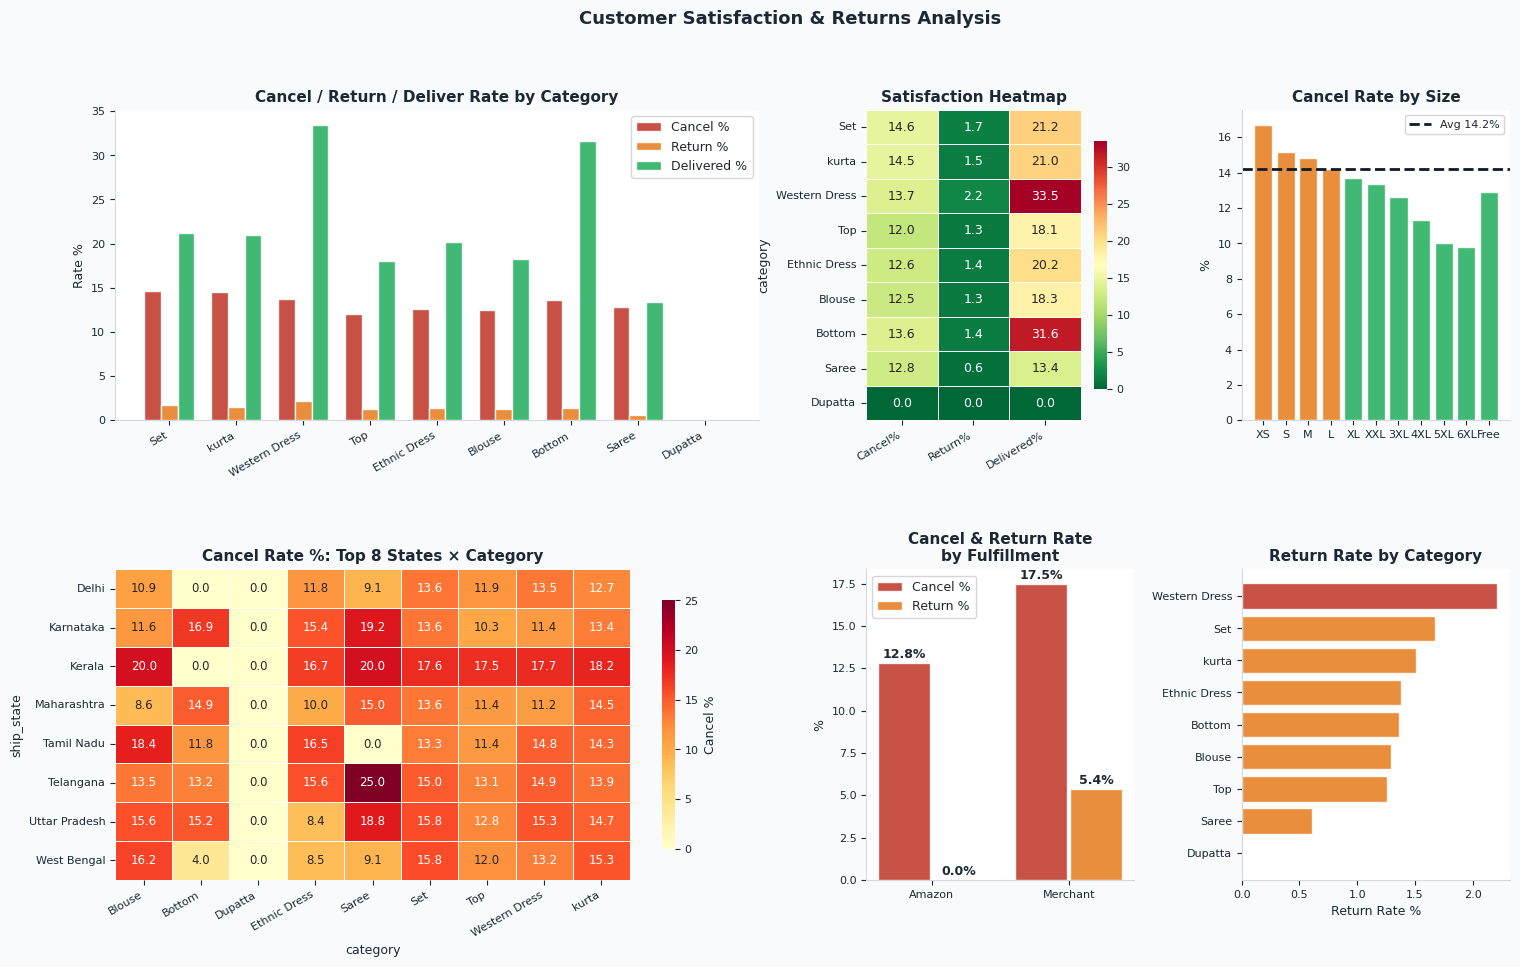

In [ ]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Customer Satisfaction & Returns Analysis", fontweight='bold', fontsize=13)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.48, wspace=0.4)

# Cancel/Return/Deliver grouped bar by category
ax = fig.add_subplot(gs[0, :2])
x_c = np.arange(len(cat_score))
w = 0.25
ax.bar(x_c - w, cat_score['cancel_%'], w, label='Cancel %', color=P['red'], edgecolor='white', alpha=0.88)
ax.bar(x_c,     cat_score['return_%'], w, label='Return %', color=P['amber'], edgecolor='white', alpha=0.88)
ax.bar(x_c + w, cat_score['delivered_%'], w, label='Delivered %', color=P['lime'], edgecolor='white', alpha=0.88)
ax.set_xticks(x_c)
ax.set_xticklabels(cat_score['category'], rotation=30, ha='right')
ax.set_title("Cancel / Return / Deliver Rate by Category", fontweight='bold')
ax.set_ylabel("Rate %")
ax.legend(fontsize=9)

# Rates heatmap by category
ax = fig.add_subplot(gs[0, 2])
heat_sat = cat_score[['category','cancel_%','return_%','delivered_%']].set_index('category')
sns.heatmap(heat_sat, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.1f',
            linewidths=0.5, annot_kws={'size':9},
            cbar_kws={'shrink':0.8})
ax.set_title("Satisfaction Heatmap", fontweight='bold')
ax.set_xticklabels(['Cancel%','Return%','Delivered%'], rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Size cancel rate ordered
ax = fig.add_subplot(gs[0, 3])
sc_c = size_perf_ord['cancel_%']
ax.bar(size_perf_ord['size'], sc_c,
       color=[P['red'] if v > 18 else P['amber'] if v > 14 else P['lime'] for v in sc_c],
       edgecolor='white', alpha=0.88)
ax.axhline(cancel_rate, color=P['navy'], ls='--', lw=2, label=f'Avg {cancel_rate:.1f}%')
ax.set_title("Cancel Rate by Size", fontweight='bold')
ax.set_ylabel("%")
ax.legend(fontsize=8)

# State cancel heatmap vs category
ax = fig.add_subplot(gs[1, :2])
top8_states = state_stats.head(8)['ship_state'].tolist()
cancel_hm = (df[df['ship_state'].isin(top8_states)]
             .groupby(['ship_state','category'])['is_cancelled']
             .mean().unstack(fill_value=0) * 100)
sns.heatmap(cancel_hm, ax=ax, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, annot_kws={'size':8.5},
            cbar_kws={'shrink':0.8, 'label':'Cancel %'})
ax.set_title("Cancel Rate %: Top 8 States × Category", fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Cancel rate: Fulfilment bars
ax = fig.add_subplot(gs[1, 2])
x_rf = np.arange(2)
ax.bar(x_rf - 0.2, ful_perf['cancel_%'], 0.38, label='Cancel %',
       color=P['red'], edgecolor='white', alpha=0.88)
ax.bar(x_rf + 0.2, ful_perf['return_%'], 0.38, label='Return %',
       color=P['amber'], edgecolor='white', alpha=0.88)
ax.set_xticks(x_rf)
ax.set_xticklabels(ful_perf['fulfilment'])
ax.set_title("Cancel & Return Rate\nby Fulfillment", fontweight='bold')
ax.set_ylabel("%")
ax.legend(fontsize=9)
for i, (c, r) in enumerate(zip(ful_perf['cancel_%'], ful_perf['return_%'])):
    ax.text(i-0.2, c+0.3, f'{c:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.text(i+0.2, r+0.3, f'{r:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Return rate by category bar
ax = fig.add_subplot(gs[1, 3])
ret_sorted = cat_score.sort_values('return_%', ascending=False)
ax.barh(ret_sorted['category'][::-1], ret_sorted['return_%'][::-1],
        color=[P['red'] if v > 2 else P['amber'] if v > 0.5 else P['lime']
               for v in ret_sorted['return_%'][::-1]],
        edgecolor='white', alpha=0.88)
ax.set_title("Return Rate by Category", fontweight='bold')
ax.set_xlabel("Return Rate %")

plt.tight_layout()
plt.show()


### Time Series Analysis

In [ ]:
import calendar

In [ ]:
df['date']          = pd.to_datetime(df['date'], errors='coerce')
df['day_name']      = df['date'].dt.day_name()
df['day_num']       = df['date'].dt.dayofweek
df['day_of_month']  = df['date'].dt.day
df['week_number']   = df['date'].dt.isocalendar().week.astype(int)
df['month_num']     = df['date'].dt.month
df['month_name']    = df['date'].dt.strftime('%B')
df['quarter']       = df['date'].dt.quarter
df['year']          = df['date'].dt.year
df['month_year']    = df['date'].dt.to_period('M').astype(str)
df['week_year']     = df['date'].dt.to_period('W').astype(str)
df['is_weekend']    = df['day_num'].isin([5, 6]).astype(int)

WEEKDAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
MONTH_ORDER   = list(calendar.month_name)[1:]


def reindex_days(series, order=WEEKDAY_ORDER):
    return series.reindex([d for d in order if d in series.index or True],
                           fill_value=0)

In [ ]:
sub("Daily Time-Series — Orders, Revenue, AOV, Cancel Rate")
daily = (df.groupby('date')
           .agg(
               orders        = ('order_id',    'count'),
               revenue       = ('amount',      'sum'),
               qty           = ('qty',         'sum'),
               cancelled     = ('is_cancelled','sum'),
               delivered     = ('is_delivered','sum'),
               aov           = ('amount',      'mean'),
               unique_skus   = ('sku',         'nunique'),
               unique_states = ('ship_state',  'nunique'),
           )
           .reset_index()
           .sort_values('date'))
daily['cancel_rate_%']   = (daily['cancelled'] / daily['orders'] * 100).round(2)
daily['deliver_rate_%']  = (daily['delivered'] / daily['orders'] * 100).round(2)
daily['revenue_7d_ma']   = daily['revenue'].rolling(window=min(7, len(daily)), min_periods=1).mean()
daily['orders_7d_ma']    = daily['orders'].rolling(window=min(7, len(daily)), min_periods=1).mean()
daily['day_label']       = daily['date'].dt.strftime('%d %b %Y (%a)')

print(f"  │  {'Date':<22}  {'Orders':>7}  {'Revenue':>12}  {'AOV':>10}  {'Cancel%':>9}  {'Deliver%':>10}  {'SKUs':>6}")
print("  │  " + "─"*86)
for _, r in daily.iterrows():
    print(f"  │  {r['day_label']:<22}  {int(r['orders']):>7}  "
          f"₹{r['revenue']:>10,.0f}  ₹{r['aov']:>8,.0f}  "
          f"{r['cancel_rate_%']:>8.2f}%  {r['deliver_rate_%']:>9.2f}%  {int(r['unique_skus']):>6}")
end_sub()


  ┌── Daily Time-Series — Orders, Revenue, AOV, Cancel Rate
  │
  │  Date                     Orders       Revenue         AOV    Cancel%    Deliver%    SKUs
  │  ──────────────────────────────────────────────────────────────────────────────────────
  │  31 Mar 2022 (Thu)           171  ₹    95,355  ₹     558     10.53%       9.36%     149
  │  01 Apr 2022 (Fri)          1470  ₹   782,462  ₹     532     15.92%      16.33%     932
  │  02 Apr 2022 (Sat)          1555  ₹   812,745  ₹     523     16.46%      15.95%     937
  │  03 Apr 2022 (Sun)          1691  ₹   925,594  ₹     547     14.25%      18.51%    1056
  │  04 Apr 2022 (Mon)          1465  ₹   814,253  ₹     556     13.52%      20.55%     970
  │  05 Apr 2022 (Tue)          1616  ₹   880,784  ₹     545     12.87%      18.56%    1034
  │  06 Apr 2022 (Wed)          1557  ₹   818,278  ₹     526     12.85%      20.55%    1018
  │  07 Apr 2022 (Thu)          1535  ₹   814,016  ₹     530     15.90%      21.11%     981
  │  08 Apr 2

In [ ]:
if len(daily) > 1:
    sub("Day-over-Day Growth Rates")
    daily['rev_dod_growth%']    = daily['revenue'].pct_change() * 100
    daily['orders_dod_growth%'] = daily['orders'].pct_change() * 100
    for _, r in daily.dropna(subset=['rev_dod_growth%']).iterrows():
        direction_r = "📈" if r['rev_dod_growth%'] > 0 else "📉"
        direction_o = "📈" if r['orders_dod_growth%'] > 0 else "📉"
        print(f"  │  {r['day_label']}")
        print(f"  │    Revenue growth   : {r['rev_dod_growth%']:>+8.2f}%  {direction_r}")
        print(f"  │    Orders growth    : {r['orders_dod_growth%']:>+8.2f}%  {direction_o}")
    end_sub()


  ┌── Day-over-Day Growth Rates
  │
  │  01 Apr 2022 (Fri)
  │    Revenue growth   :  +720.58%  📈
  │    Orders growth    :  +759.65%  📈
  │  02 Apr 2022 (Sat)
  │    Revenue growth   :    +3.87%  📈
  │    Orders growth    :    +5.78%  📈
  │  03 Apr 2022 (Sun)
  │    Revenue growth   :   +13.88%  📈
  │    Orders growth    :    +8.75%  📈
  │  04 Apr 2022 (Mon)
  │    Revenue growth   :   -12.03%  📉
  │    Orders growth    :   -13.36%  📉
  │  05 Apr 2022 (Tue)
  │    Revenue growth   :    +8.17%  📈
  │    Orders growth    :   +10.31%  📈
  │  06 Apr 2022 (Wed)
  │    Revenue growth   :    -7.10%  📉
  │    Orders growth    :    -3.65%  📉
  │  07 Apr 2022 (Thu)
  │    Revenue growth   :    -0.52%  📉
  │    Orders growth    :    -1.41%  📉
  │  08 Apr 2022 (Fri)
  │    Revenue growth   :   +13.41%  📈
  │    Orders growth    :    +9.19%  📈
  │  09 Apr 2022 (Sat)
  │    Revenue growth   :    -4.78%  📉
  │    Orders growth    :    -3.40%  📉
  │  10 Apr 2022 (Sun)
  │    Revenue growth   :   +12

In [ ]:
sub("Weekday Analysis — Sales Performance by Day of Week")

weekday = (df.groupby('day_name')
             .agg(
                 orders       = ('order_id',    'count'),
                 revenue      = ('amount',      'sum'),
                 qty          = ('qty',         'sum'),
                 cancelled    = ('is_cancelled','sum'),
                 delivered    = ('is_delivered','sum'),
                 aov          = ('amount',      'mean'),
                 b2b_orders   = ('b2b_int',     'sum'),
                 promo_orders = ('has_promo',   'sum'),
             )
             .reset_index())

weekday['cancel_rate_%']  = (weekday['cancelled'] / weekday['orders'] * 100).round(2)
weekday['deliver_rate_%'] = (weekday['delivered'] / weekday['orders'] * 100).round(2)
weekday['promo_rate_%']   = (weekday['promo_orders'] / weekday['orders'] * 100).round(2)
weekday['rev_share_%']    = (weekday['revenue'] / weekday['revenue'].sum() * 100).round(2)
weekday['order_share_%']  = (weekday['orders']  / weekday['orders'].sum()  * 100).round(2)

# Sort by weekday order (only show days present)
weekday['sort_key'] = weekday['day_name'].map(
    {d: i for i, d in enumerate(WEEKDAY_ORDER)})
weekday = weekday.sort_values('sort_key').reset_index(drop=True)

print(f"\n  │  {'Day':<12}  {'Orders':>7}  {'Order%':>7}  {'Revenue':>12}  {'Rev%':>7}  "
      f"{'AOV':>10}  {'Cancel%':>9}  {'Promo%':>8}")
print("  │  " + "─"*88)
for _, r in weekday.iterrows():
    bar = '█' * int(r['rev_share_%'] / 2)
    flag = "  ★ HIGHEST" if r['revenue'] == weekday['revenue'].max() else \
           "  ▲ 2nd"    if r['revenue'] == weekday['revenue'].nlargest(2).iloc[-1] else ""
    print(f"  │  {r['day_name']:<12}  {int(r['orders']):>7}  {r['order_share_%']:>6.1f}%  "
          f"₹{r['revenue']:>10,.0f}  {r['rev_share_%']:>6.1f}%  "
          f"₹{r['aov']:>8,.0f}  {r['cancel_rate_%']:>8.2f}%  "
          f"{r['promo_rate_%']:>7.1f}%  {bar}{flag}")

print("  │")
best_day_rev    = weekday.loc[weekday['revenue'].idxmax(),    'day_name']
best_day_orders = weekday.loc[weekday['orders'].idxmax(),     'day_name']
best_day_aov    = weekday.loc[weekday['aov'].idxmax(),        'day_name']
worst_cancel    = weekday.loc[weekday['cancel_rate_%'].idxmax(),'day_name']
print(f"  │  ► Highest Revenue Day   : {best_day_rev}")
print(f"  │  ► Highest Orders Day    : {best_day_orders}")
print(f"  │  ► Highest AOV Day       : {best_day_aov}")
print(f"  │  ► Highest Cancel Day    : {worst_cancel}")
end_sub()



  ┌── Weekday Analysis — Sales Performance by Day of Week
  │

  │  Day            Orders   Order%       Revenue     Rev%         AOV    Cancel%    Promo%
  │  ────────────────────────────────────────────────────────────────────────────────────────
  │  Monday          18559    14.4%  ₹10,301,063    14.4%  ₹     555     14.53%    100.0%  ███████
  │  Tuesday         18872    14.6%  ₹10,487,472    14.6%  ₹     556     14.37%    100.0%  ███████  ▲ 2nd
  │  Wednesday       18581    14.4%  ₹10,311,378    14.4%  ₹     555     14.06%    100.0%  ███████
  │  Thursday        17066    13.2%  ₹ 9,489,732    13.2%  ₹     556     14.16%    100.0%  ██████
  │  Friday          17709    13.7%  ₹ 9,859,181    13.7%  ₹     557     14.39%    100.0%  ██████
  │  Saturday        18505    14.3%  ₹10,297,317    14.3%  ₹     556     14.30%    100.0%  ███████
  │  Sunday          19618    15.2%  ₹11,009,530    15.3%  ₹     561     13.77%    100.0%  ███████  ★ HIGHEST
  │
  │  ► Highest Revenue Day   : Sunday

In [ ]:
sub("Weekend vs Weekday — Statistical Comparison")

wknd = df[df['is_weekend'] == 1]
wkdy = df[df['is_weekend'] == 0]

print(f"  │  {'Metric':<35}  {'Weekday':>14}  {'Weekend':>14}  {'Delta':>12}")
print("  │  " + "─"*80)
metrics_ww = [
    ("Avg Daily Orders",
     wkdy.groupby('date')['order_id'].count().mean(),
     wknd.groupby('date')['order_id'].count().mean()),
    ("Avg Daily Revenue (₹)",
     wkdy.groupby('date')['amount'].sum().mean(),
     wknd.groupby('date')['amount'].sum().mean()),
    ("Mean Order Value (₹)",
     wkdy['amount'].mean(),
     wknd['amount'].mean()),
    ("Cancellation Rate (%)",
     wkdy['is_cancelled'].mean() * 100,
     wknd['is_cancelled'].mean() * 100),
    ("Delivery Rate (%)",
     wkdy['is_delivered'].mean() * 100,
     wknd['is_delivered'].mean() * 100),
    ("Promo Usage Rate (%)",
     wkdy['has_promo'].mean() * 100,
     wknd['has_promo'].mean() * 100),
    ("Avg Qty per Order",
     wkdy['qty'].mean(),
     wknd['qty'].mean()),
]
for label, wd_val, we_val in metrics_ww:
    delta = we_val - wd_val
    arrow = "↑" if delta > 0 else "↓"
    print(f"  │  {label:<35}  {wd_val:>14.2f}  {we_val:>14.2f}  {arrow}{abs(delta):>10.2f}")

# Mann-Whitney test: weekday vs weekend amounts
if len(wkdy) > 0 and len(wknd) > 0:
    u_ww, p_ww = mannwhitneyu(wkdy['amount'], wknd['amount'], alternative='two-sided')
    print(f"  │")
    print(f"  │  Mann-Whitney U (Weekday vs Weekend Amount): U={u_ww:.0f}, p={p_ww:.4e}")
    print(f"  │  → {'Statistically significant difference' if p_ww < 0.05 else 'No significant difference'} (α=0.05)")
end_sub()


  ┌── Weekend vs Weekday — Statistical Comparison
  │
  │  Metric                                      Weekday         Weekend         Delta
  │  ────────────────────────────────────────────────────────────────────────────────
  │  Avg Daily Orders                            1396.72         1466.27  ↑     69.55
  │  Avg Daily Revenue (₹)                     776135.78       819494.10  ↑  43358.32
  │  Mean Order Value (₹)                         555.68          558.90  ↑      3.21
  │  Cancellation Rate (%)                         14.30           14.03  ↓      0.28
  │  Delivery Rate (%)                             22.35           22.23  ↓      0.12
  │  Promo Usage Rate (%)                         100.00          100.00  ↓      0.00
  │  Avg Qty per Order                              0.90            0.91  ↑      0.01
  │
  │  Mann-Whitney U (Weekday vs Weekend Amount): U=1717996036, p=3.9306e-02
  │  → Statistically significant difference (α=0.05)
  │


In [ ]:
sub("Monthly Analysis — Revenue, Orders, AOV, Cancel Rate")

monthly = (df.groupby(['month_year', 'month_name', 'month_num', 'year'])
             .agg(
                 orders       = ('order_id',    'count'),
                 revenue      = ('amount',      'sum'),
                 qty          = ('qty',         'sum'),
                 cancelled    = ('is_cancelled','sum'),
                 delivered    = ('is_delivered','sum'),
                 unique_skus  = ('sku',         'nunique'),
                 aov          = ('amount',      'mean'),
                 unique_cities= ('ship_city',   'nunique'),
             )
             .reset_index()
             .sort_values(['year','month_num']))

monthly['cancel_rate_%']  = (monthly['cancelled'] / monthly['orders'] * 100).round(2)
monthly['deliver_rate_%'] = (monthly['delivered'] / monthly['orders'] * 100).round(2)
monthly['rev_share_%']    = (monthly['revenue']  / monthly['revenue'].sum() * 100).round(2)
monthly['mom_rev_growth'] = monthly['revenue'].pct_change() * 100
monthly['mom_ord_growth'] = monthly['orders'].pct_change() * 100

print(f"  │  {'Month-Year':<12}  {'Orders':>7}  {'Revenue':>12}  {'AOV':>10}  "
      f"{'Cancel%':>9}  {'Deliver%':>10}  {'MoM Rev%':>10}")
print("  │  " + "─"*88)
for _, r in monthly.iterrows():
    mom_str = f"{r['mom_rev_growth']:>+8.1f}%" if pd.notna(r['mom_rev_growth']) else "        —"
    print(f"  │  {r['month_year']:<12}  {int(r['orders']):>7}  "
          f"₹{r['revenue']:>10,.0f}  ₹{r['aov']:>8,.0f}  "
          f"{r['cancel_rate_%']:>8.2f}%  {r['deliver_rate_%']:>9.2f}%  {mom_str}")
end_sub()


  ┌── Monthly Analysis — Revenue, Orders, AOV, Cancel Rate
  │
  │  Month-Year     Orders       Revenue         AOV    Cancel%    Deliver%    MoM Rev%
  │  ────────────────────────────────────────────────────────────────────────────────────────
  │  2022-03           171  ₹    95,355  ₹     558     10.53%       9.36%          —
  │  2022-04         49043  ₹26,272,650  ₹     536     14.54%      24.64%  +27452.5%
  │  2022-05         42020  ₹23,975,445  ₹     571     13.99%      24.74%      -8.7%
  │  2022-06         37676  ₹21,412,223  ₹     568     14.07%      16.63%     -10.7%
  │


In [ ]:
sub("Quarterly Aggregation")
quarterly = (df.groupby(['year','quarter'])
               .agg(orders=('order_id','count'), revenue=('amount','sum'),
                    cancelled=('is_cancelled','sum'), aov=('amount','mean'))
               .reset_index())
quarterly['cancel_rate_%'] = (quarterly['cancelled']/quarterly['orders']*100).round(2)
quarterly['quarter_label'] = 'Q' + quarterly['quarter'].astype(str) + '-' + quarterly['year'].astype(str)
for _, r in quarterly.iterrows():
    print(f"  │  {r['quarter_label']:<10}  orders={int(r['orders']):>5}  "
          f"revenue=₹{r['revenue']:>10,.0f}  aov=₹{r['aov']:>8,.0f}  "
          f"cancel={r['cancel_rate_%']:.2f}%")
end_sub()


  ┌── Quarterly Aggregation
  │
  │  Q1-2022     orders=  171  revenue=₹    95,355  aov=₹     558  cancel=10.53%
  │  Q2-2022     orders=128739  revenue=₹71,660,318  aov=₹     557  cancel=14.22%
  │


In [ ]:
sub("Weekday × Category Revenue Matrix")
wdc = df.groupby(['day_name','category'])['amount'].sum().unstack(fill_value=0)
wdc = wdc.reindex([d for d in WEEKDAY_ORDER if d in wdc.index])
print(wdc.to_string())
end_sub()




  ┌── Weekday × Category Revenue Matrix
  │
category    Blouse   Bottom  Dupatta  Ethnic Dress    Saree         Set       Top  Western Dress       kurta
day_name                                                                                                    
Monday     60614.0  20587.0      0.0       96796.0   5036.0  5149199.00  710563.0      1436863.0  2821405.00
Tuesday    59870.0  20745.0      0.0      127027.0  11237.0  5243137.00  727673.0      1468339.0  2829444.00
Wednesday  65130.0  18763.0      0.0      108870.0  17167.0  5034584.00  714620.0      1526510.0  2825734.00
Thursday   58357.0  16010.0      0.0       99537.0  21387.0  4683557.00  610381.0      1354872.0  2645631.00
Friday     60419.0  20352.0      0.0       94910.0  12756.0  4982108.00  621545.0      1453557.0  2613534.00
Saturday   61080.0  20341.0      0.0      103354.0  28488.0  5130063.14  710659.0      1483587.0  2759744.48
Sunday     55099.0  19200.0    915.0      101567.0  18623.0  5545889.00  812491.0  

In [ ]:

sub("Weekday × Category Cancel Rate (%)")
wdc_cancel = (df.groupby(['day_name','category'])['is_cancelled']
               .mean().unstack(fill_value=0) * 100)
wdc_cancel = wdc_cancel.reindex([d for d in WEEKDAY_ORDER if d in wdc_cancel.index])
print(wdc_cancel.round(2).to_string())
end_sub()


  ┌── Weekday × Category Cancel Rate (%)
  │
category   Blouse  Bottom  Dupatta  Ethnic Dress  Saree    Set    Top  Western Dress  kurta
day_name                                                                                   
Monday      11.81   14.71      0.0         12.66  46.15  15.01  12.76          14.32  14.52
Tuesday     16.91   13.85      0.0         10.68  36.84  15.11  11.78          12.77  14.66
Wednesday    9.30   17.74      0.0         20.97  12.00  14.24  10.68          13.61  14.61
Thursday    17.73    7.84      0.0         10.46   3.45  13.97  12.43          13.83  14.88
Friday       9.70    6.90      0.0         12.95   0.00  14.85  12.03          14.39  14.62
Saturday    12.59   11.59      0.0          9.62   2.78  14.89  11.63          13.65  14.70
Sunday       8.87   20.90      0.0         10.00  11.54  14.07  12.74          13.47  13.90
  │


In [ ]:
sub("Weekday × Fulfillment Performance")
wdf = (df.groupby(['day_name','fulfilment'])
         .agg(orders=('order_id','count'), revenue=('amount','sum'),
              cancel_rate=('is_cancelled','mean'))
         .reset_index())
wdf['cancel_rate_%'] = (wdf['cancel_rate']*100).round(2)
print(wdf.sort_values(['day_name','fulfilment']).to_string(index=False))
end_sub()


  ┌── Weekday × Fulfillment Performance
  │
 day_name fulfilment  orders    revenue  cancel_rate  cancel_rate_%
   Friday     Amazon   12671 7146364.00     0.130298          13.03
   Friday   Merchant    5038 2712817.00     0.178047          17.80
   Monday     Amazon   12655 7170037.00     0.131173          13.12
   Monday   Merchant    5904 3131026.00     0.175644          17.56
 Saturday     Amazon   13114 7419956.00     0.128565          12.86
 Saturday   Merchant    5391 2877360.62     0.178075          17.81
   Sunday     Amazon   13494 7701698.00     0.123981          12.40
   Sunday   Merchant    6124 3307832.00     0.167864          16.79
 Thursday     Amazon   11949 6761049.00     0.124278          12.43
 Thursday   Merchant    5117 2728683.00     0.181943          18.19
  Tuesday     Amazon   13006 7320602.00     0.132400          13.24
  Tuesday   Merchant    5866 3166870.00     0.168599          16.86
Wednesday     Amazon   12764 7160548.00     0.124961          12.50
Wed

In [ ]:
sub("Weekday × Shipping Service Level")
wsl = (df.groupby(['day_name','ship_service_level'])
         .agg(orders=('order_id','count'), revenue=('amount','sum'),
              cancel_rate=('is_cancelled','mean'))
         .reset_index())
wsl['cancel_rate_%'] = (wsl['cancel_rate']*100).round(2)
print(wsl.sort_values(['day_name','ship_service_level']).to_string(index=False))
end_sub()


  ┌── Weekday × Shipping Service Level
  │
 day_name ship_service_level  orders    revenue  cancel_rate  cancel_rate_%
   Friday          Expedited   12502 7134549.00     0.131419          13.14
   Friday           Standard    5207 2724632.00     0.173804          17.38
   Monday          Expedited   12520 7161421.00     0.132188          13.22
   Monday           Standard    6039 3139642.00     0.172545          17.25
 Saturday          Expedited   12946 7402718.00     0.129770          12.98
 Saturday           Standard    5559 2894598.62     0.173772          17.38
   Sunday          Expedited   13325 7680620.00     0.125253          12.53
   Sunday           Standard    6293 3328910.00     0.163992          16.40
 Thursday          Expedited   11813 6746881.00     0.124947          12.49
 Thursday           Standard    5253 2742851.00     0.178945          17.89
  Tuesday          Expedited   12858 7314512.00     0.133147          13.31
  Tuesday           Standard    6014 3172960

In [ ]:
sub("Rolling Statistics (Daily)")
daily['rolling_rev_mean'] = daily['revenue'].expanding().mean()
daily['rolling_rev_std']  = daily['revenue'].expanding().std().fillna(0)
daily['upper_band']       = daily['rolling_rev_mean'] + 2 * daily['rolling_rev_std']
daily['lower_band']       = daily['rolling_rev_mean'] - 2 * daily['rolling_rev_std']
daily['above_trend']      = (daily['revenue'] > daily['rolling_rev_mean']).astype(int)
print(f"  │  {'Date':<22}  {'Revenue':>12}  {'Roll Mean':>12}  {'Upper(+2σ)':>12}  {'Lower(-2σ)':>12}  {'Above Trend?'}")
print("  │  " + "─"*92)
for _, r in daily.iterrows():
    flag = "  ✅ Yes" if r['above_trend'] else "  ⬇ No"
    print(f"  │  {r['day_label']:<22}  ₹{r['revenue']:>10,.0f}  "
          f"₹{r['rolling_rev_mean']:>10,.0f}  ₹{r['upper_band']:>10,.0f}  "
          f"₹{r['lower_band']:>10,.0f}  {flag}")
end_sub()


  ┌── Rolling Statistics (Daily)
  │
  │  Date                         Revenue     Roll Mean    Upper(+2σ)    Lower(-2σ)  Above Trend?
  │  ────────────────────────────────────────────────────────────────────────────────────────────
  │  31 Mar 2022 (Thu)       ₹    95,355  ₹    95,355  ₹    95,355  ₹    95,355    ⬇ No
  │  01 Apr 2022 (Fri)       ₹   782,462  ₹   438,908  ₹ 1,410,625  ₹  -532,808    ✅ Yes
  │  02 Apr 2022 (Sat)       ₹   812,745  ₹   563,521  ₹ 1,374,973  ₹  -247,931    ✅ Yes
  │  03 Apr 2022 (Sun)       ₹   925,594  ₹   654,039  ₹ 1,409,067  ₹  -100,989    ✅ Yes
  │  04 Apr 2022 (Mon)       ₹   814,253  ₹   686,082  ₹ 1,355,473  ₹    16,690    ✅ Yes
  │  05 Apr 2022 (Tue)       ₹   880,784  ₹   718,532  ₹ 1,338,000  ₹    99,064    ✅ Yes
  │  06 Apr 2022 (Wed)       ₹   818,278  ₹   732,782  ₹ 1,303,280  ₹   162,283    ✅ Yes
  │  07 Apr 2022 (Thu)       ₹   814,016  ₹   742,936  ₹ 1,274,230  ₹   211,642    ✅ Yes
  │  08 Apr 2022 (Fri)       ₹   923,159  ₹   762,961  

In [ ]:
sub("Top Selling Category per Weekday")
for day in [d for d in WEEKDAY_ORDER if d in df['day_name'].values]:
    day_df = df[df['day_name'] == day]
    top_cat = day_df.groupby('category')['amount'].sum().idxmax()
    top_rev = day_df.groupby('category')['amount'].sum().max()
    top_size = day_df.groupby('size')['order_id'].count().idxmax()
    print(f"  │  {day:<12}  Top Category: {top_cat:<15}  Revenue: ₹{top_rev:>9,.0f}  "
          f"Top Size: {top_size}")
end_sub()


  ┌── Top Selling Category per Weekday
  │
  │  Monday        Top Category: Set              Revenue: ₹5,149,199  Top Size: M
  │  Tuesday       Top Category: Set              Revenue: ₹5,243,137  Top Size: M
  │  Wednesday     Top Category: Set              Revenue: ₹5,034,584  Top Size: M
  │  Thursday      Top Category: Set              Revenue: ₹4,683,557  Top Size: M
  │  Friday        Top Category: Set              Revenue: ₹4,982,108  Top Size: M
  │  Saturday      Top Category: Set              Revenue: ₹5,130,063  Top Size: M
  │  Sunday        Top Category: Set              Revenue: ₹5,545,889  Top Size: L
  │


In [ ]:
sub("Intra-Day Volume Flow (Order Sequence Proxy)")
df_sorted = df.sort_values('date').reset_index(drop=True)
df_sorted['order_seq'] = df_sorted.index + 1
df_sorted['batch']     = pd.cut(df_sorted['order_seq'],
                                 bins=10,
                                 labels=[f"Batch {i}" for i in range(1,11)])
batch_stats = (df_sorted.groupby('batch', observed=True)
               .agg(orders=('order_id','count'), revenue=('amount','sum'),
                    cancel_rate=('is_cancelled','mean'))
               .reset_index())
batch_stats['cancel_%'] = (batch_stats['cancel_rate']*100).round(2)
print(f"  │  {'Batch (order seq)':<18}  {'Orders':>7}  {'Revenue':>12}  {'Cancel%':>9}")
print("  │  " + "─"*54)
for _, r in batch_stats.iterrows():
    bar = '█' * int(r['revenue'] / batch_stats['revenue'].max() * 25)
    print(f"  │  {str(r['batch']):<18}  {int(r['orders']):>7}  ₹{r['revenue']:>10,.0f}  "
          f"{r['cancel_%']:>8.2f}%  {bar}")
end_sub()


  ┌── Intra-Day Volume Flow (Order Sequence Proxy)
  │
  │  Batch (order seq)    Orders       Revenue    Cancel%
  │  ──────────────────────────────────────────────────────
  │  Batch 1               12891  ₹ 6,951,355     14.49%  ██████████████████████
  │  Batch 2               12891  ₹ 6,930,660     15.22%  ██████████████████████
  │  Batch 3               12891  ₹ 6,855,379     13.88%  ██████████████████████
  │  Batch 4               12891  ₹ 6,906,816     14.38%  ██████████████████████
  │  Batch 5               12891  ₹ 7,144,881     14.52%  ███████████████████████
  │  Batch 6               12891  ₹ 7,393,271     14.69%  ████████████████████████
  │  Batch 7               12891  ₹ 7,559,497     12.83%  █████████████████████████
  │  Batch 8               12891  ₹ 7,323,712     13.99%  ████████████████████████
  │  Batch 9               12891  ₹ 7,356,234     14.32%  ████████████████████████
  │  Batch 10              12891  ₹ 7,333,868     13.88%  ████████████████████████
  │


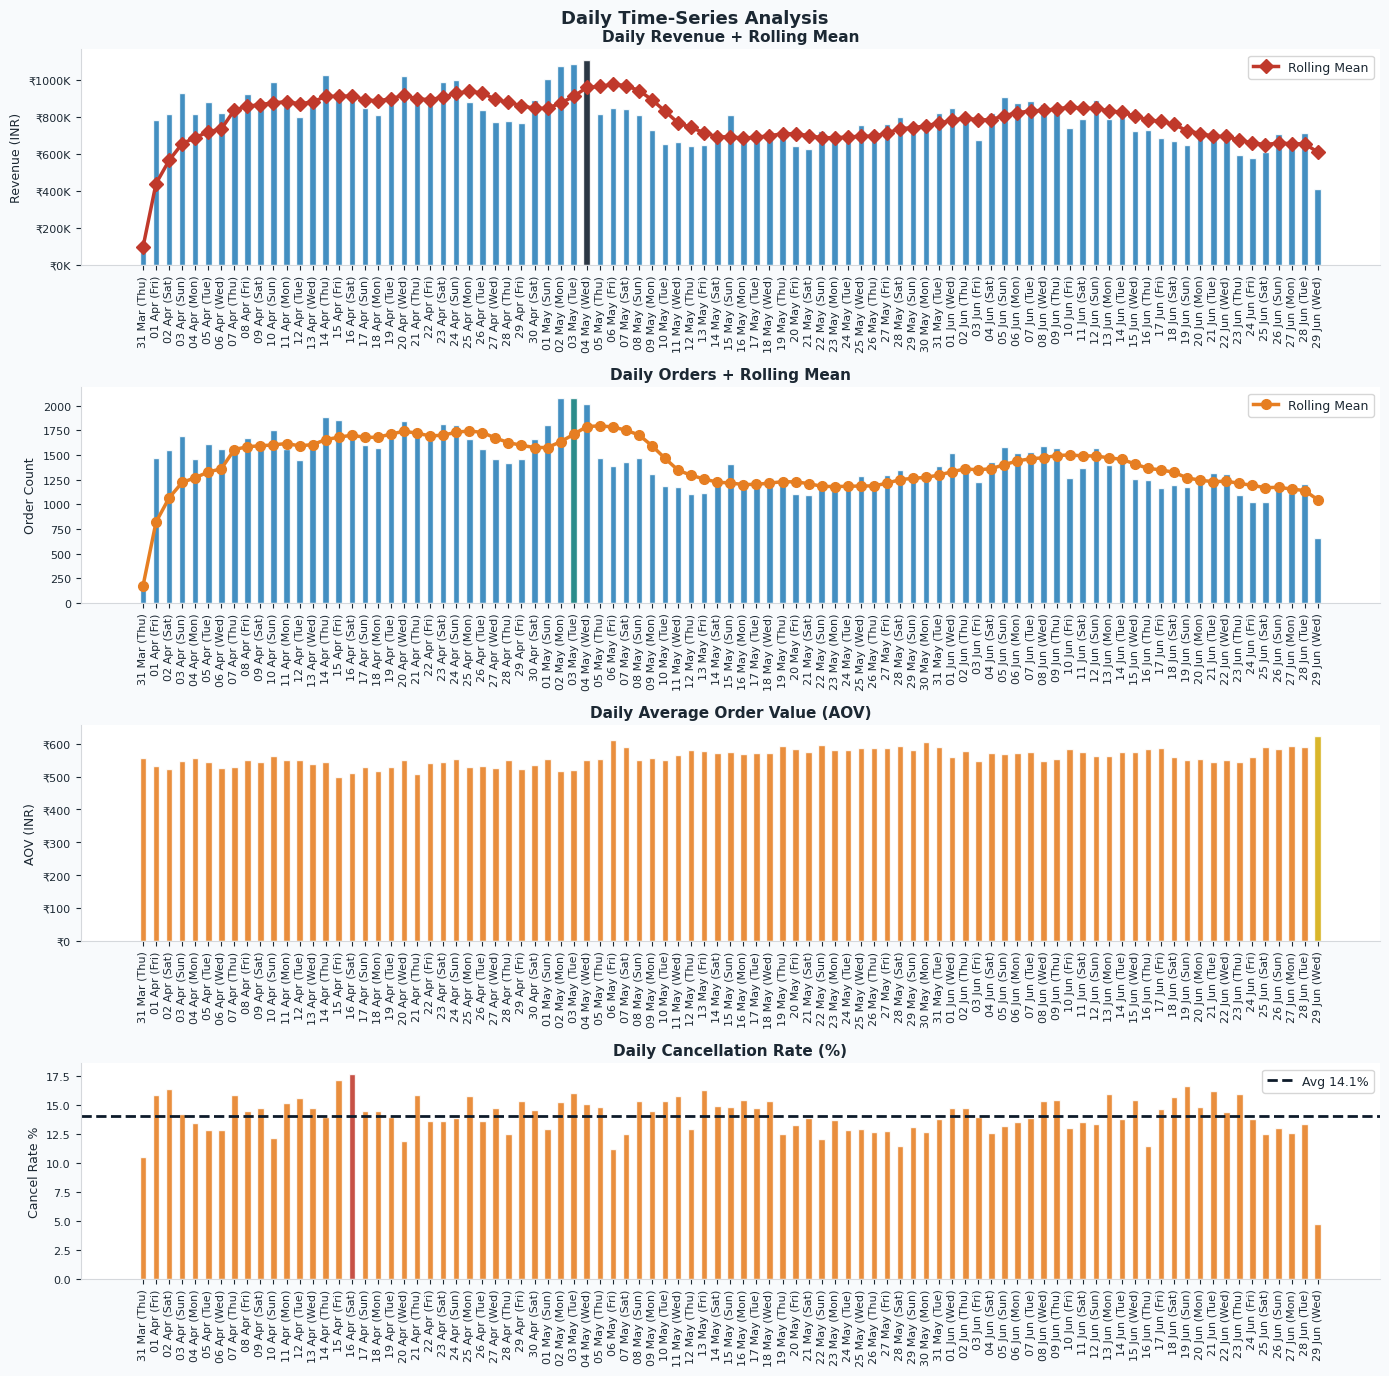

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
fig.suptitle("Daily Time-Series Analysis", fontweight='bold', fontsize=13)

x_labels = daily['date'].dt.strftime('%d %b (%a)')

# a) Revenue
ax = axes[0]

ax.bar(
    x_labels,
    daily['revenue'],
    color=[P['navy'] if v == daily['revenue'].max() else P['sky'] for v in daily['revenue']],
    edgecolor='white',
    alpha=0.88,
    width=0.5
)

ax.plot(
    range(len(daily)),
    daily['revenue_7d_ma'],
    color=P['red'],
    lw=2.5,
    marker='D',
    ms=7,
    label='Rolling Mean',
    zorder=5
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))

ax.set_title("Daily Revenue + Rolling Mean", fontweight='bold')
ax.set_ylabel("Revenue (INR)")
ax.legend(fontsize=9)

ax.tick_params(axis='x', rotation=90)


# b) Orders
ax = axes[1]

ax.bar(
    x_labels,
    daily['orders'],
    color=[P['teal'] if v == daily['orders'].max() else P['sky'] for v in daily['orders']],
    edgecolor='white',
    alpha=0.88,
    width=0.5
)

ax.plot(
    range(len(daily)),
    daily['orders_7d_ma'],
    color=P['amber'],
    lw=2.5,
    marker='o',
    ms=7,
    label='Rolling Mean'
)

ax.set_title("Daily Orders + Rolling Mean", fontweight='bold')
ax.set_ylabel("Order Count")
ax.legend(fontsize=9)

ax.tick_params(axis='x', rotation=90)


# c) AOV
ax = axes[2]

ax.bar(
    x_labels,
    daily['aov'],
    color=[P['gold'] if v == daily['aov'].max() else P['amber'] for v in daily['aov']],
    edgecolor='white',
    alpha=0.88,
    width=0.5
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v:.0f}'))

ax.set_title("Daily Average Order Value (AOV)", fontweight='bold')
ax.set_ylabel("AOV (INR)")

ax.tick_params(axis='x', rotation=90)


# d) Cancel rate
ax = axes[3]

ax.bar(
    x_labels,
    daily['cancel_rate_%'],
    color=[P['red'] if v == daily['cancel_rate_%'].max() else P['amber']
           for v in daily['cancel_rate_%']],
    edgecolor='white',
    alpha=0.88,
    width=0.5
)

ax.axhline(
    daily['cancel_rate_%'].mean(),
    color=P['navy'],
    ls='--',
    lw=2,
    label=f"Avg {daily['cancel_rate_%'].mean():.1f}%"
)

ax.set_title("Daily Cancellation Rate (%)", fontweight='bold')
ax.set_ylabel("Cancel Rate %")
ax.legend(fontsize=9)

ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

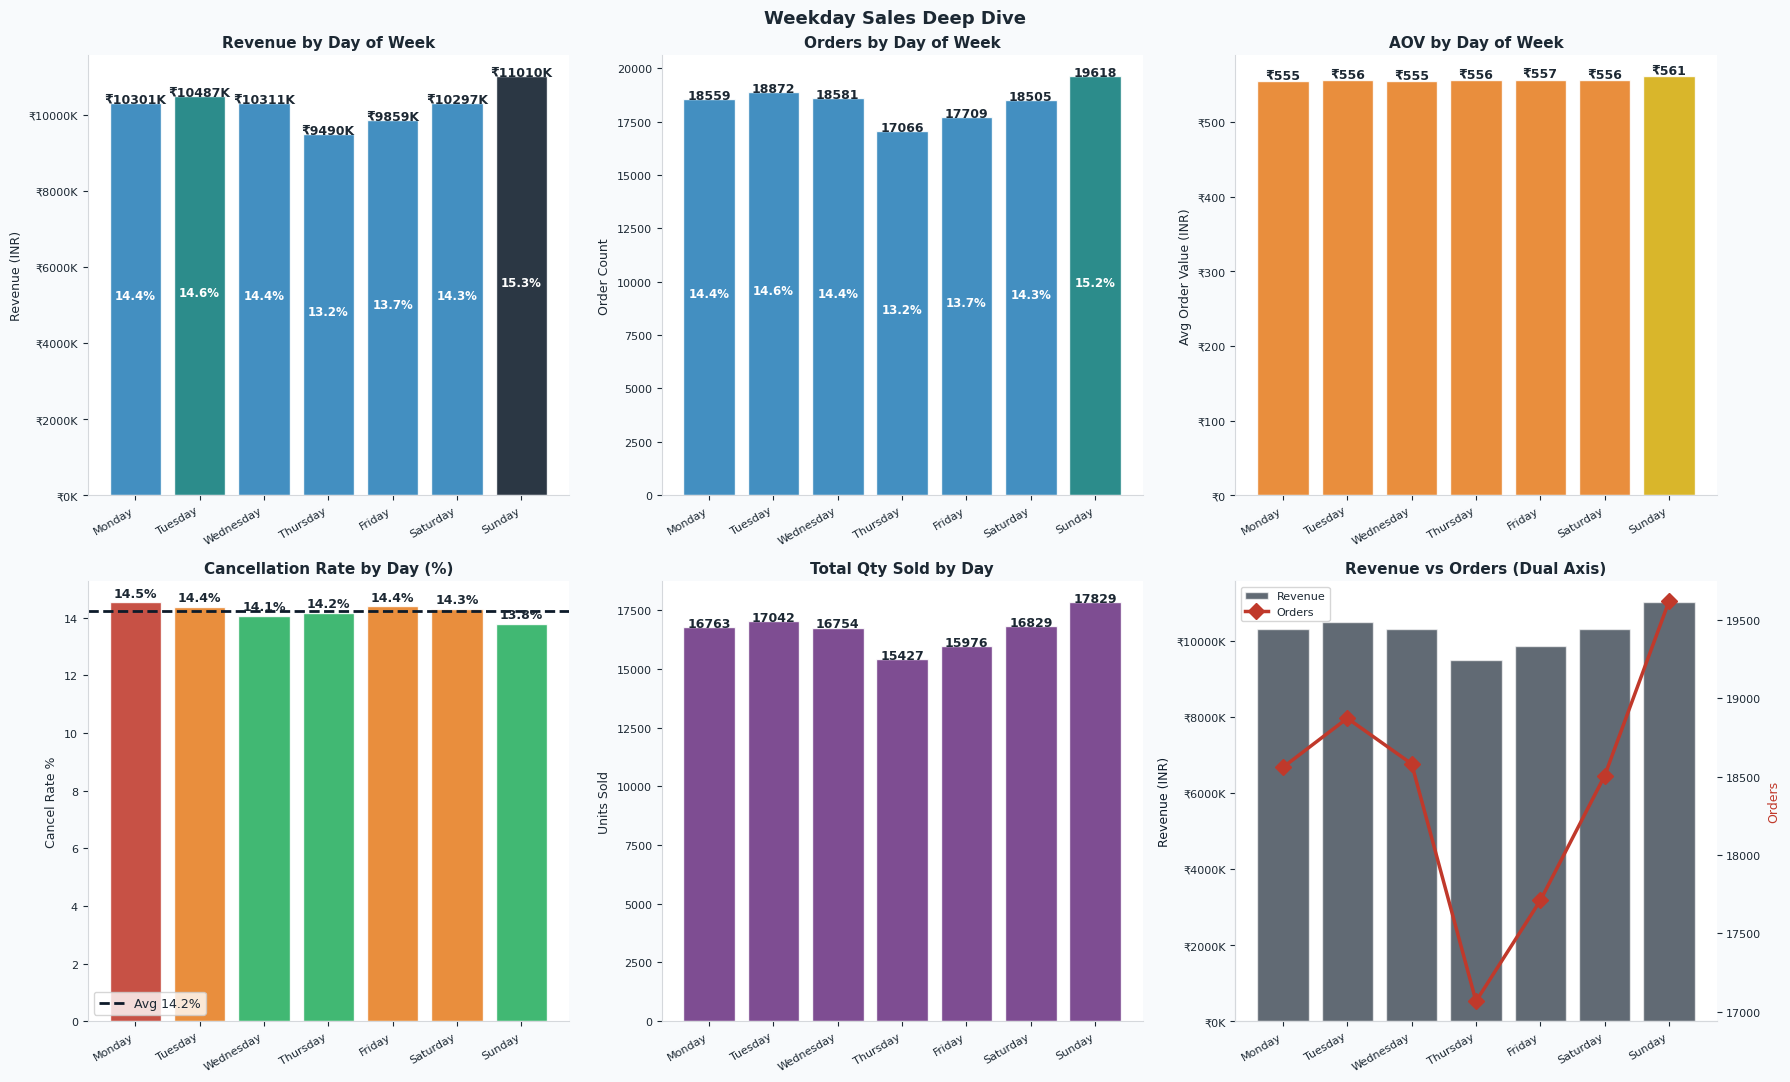

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Weekday Sales Deep Dive", fontweight='bold', fontsize=13)

days_present  = weekday['day_name'].tolist()
day_colors    = [P['navy'] if v == weekday['revenue'].max() else
                 P['teal'] if v == weekday['revenue'].nlargest(2).iloc[-1] else P['sky']
                 for v in weekday['revenue']]

# a) Revenue by weekday
ax = axes[0, 0]
ax.bar(days_present, weekday['revenue'], color=day_colors, edgecolor='white', alpha=0.88)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
ax.set_title("Revenue by Day of Week", fontweight='bold')
ax.set_ylabel("Revenue (INR)")
ax.set_xticklabels(days_present, rotation=30, ha='right')
for i, (_, r) in enumerate(weekday.iterrows()):
    ax.text(i, r['revenue']+2000, f"₹{r['revenue']/1000:.0f}K",
            ha='center', fontsize=9, fontweight='bold')
    ax.text(i, r['revenue']/2, f"{r['rev_share_%']:.1f}%",
            ha='center', fontsize=8.5, color='white', fontweight='bold')

# b) Orders by weekday
ax = axes[0, 1]
order_colors = [P['teal'] if v == weekday['orders'].max() else P['sky']
                for v in weekday['orders']]
ax.bar(days_present, weekday['orders'], color=order_colors, edgecolor='white', alpha=0.88)
ax.set_title("Orders by Day of Week", fontweight='bold')
ax.set_ylabel("Order Count")
ax.set_xticklabels(days_present, rotation=30, ha='right')
for i, (_, r) in enumerate(weekday.iterrows()):
    ax.text(i, r['orders']+5, str(int(r['orders'])),
            ha='center', fontsize=9, fontweight='bold')
    ax.text(i, r['orders']/2, f"{r['order_share_%']:.1f}%",
            ha='center', fontsize=8.5, color='white', fontweight='bold')

# c) AOV by weekday
ax = axes[0, 2]
aov_colors = [P['gold'] if v == weekday['aov'].max() else P['amber']
              for v in weekday['aov']]
ax.bar(days_present, weekday['aov'], color=aov_colors, edgecolor='white', alpha=0.88)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v:.0f}'))
ax.set_title("AOV by Day of Week", fontweight='bold')
ax.set_ylabel("Avg Order Value (INR)")
ax.set_xticklabels(days_present, rotation=30, ha='right')
for i, (_, r) in enumerate(weekday.iterrows()):
    ax.text(i, r['aov']+3, f"₹{r['aov']:.0f}",
            ha='center', fontsize=9, fontweight='bold')

# d) Cancel rate by weekday
ax = axes[1, 0]
cancel_colors = [P['red'] if v == weekday['cancel_rate_%'].max() else
                 P['amber'] if v > weekday['cancel_rate_%'].mean() else P['lime']
                 for v in weekday['cancel_rate_%']]
ax.bar(days_present, weekday['cancel_rate_%'], color=cancel_colors,
       edgecolor='white', alpha=0.88)
ax.axhline(weekday['cancel_rate_%'].mean(), color=P['navy'], ls='--', lw=2,
           label=f"Avg {weekday['cancel_rate_%'].mean():.1f}%")
ax.set_title("Cancellation Rate by Day (%)", fontweight='bold')
ax.set_ylabel("Cancel Rate %")
ax.set_xticklabels(days_present, rotation=30, ha='right')
ax.legend(fontsize=9)
for i, v in enumerate(weekday['cancel_rate_%']):
    ax.text(i, v+0.2, f"{v:.1f}%", ha='center', fontsize=9, fontweight='bold')

# e) Qty sold by weekday
ax = axes[1, 1]
ax.bar(days_present, weekday['qty'], color=P['purple'], edgecolor='white', alpha=0.88)
ax.set_title("Total Qty Sold by Day", fontweight='bold')
ax.set_ylabel("Units Sold")
ax.set_xticklabels(days_present, rotation=30, ha='right')
for i, v in enumerate(weekday['qty']):
    ax.text(i, v+5, str(int(v)), ha='center', fontsize=9, fontweight='bold')

# f) Revenue + Orders dual axis
ax = axes[1, 2]
ax2f = ax.twinx()
ax.bar(days_present, weekday['revenue'], color=P['navy'], alpha=0.65,
       edgecolor='white', label='Revenue')
ax2f.plot(days_present, weekday['orders'], color=P['red'],
          marker='D', lw=2.5, ms=8, label='Orders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
ax.set_title("Revenue vs Orders (Dual Axis)", fontweight='bold')
ax.set_ylabel("Revenue (INR)", color=P['navy'])
ax2f.set_ylabel("Orders", color=P['red'])
ax.set_xticklabels(days_present, rotation=30, ha='right')
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2f.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, fontsize=8)

plt.tight_layout()
plt.show()

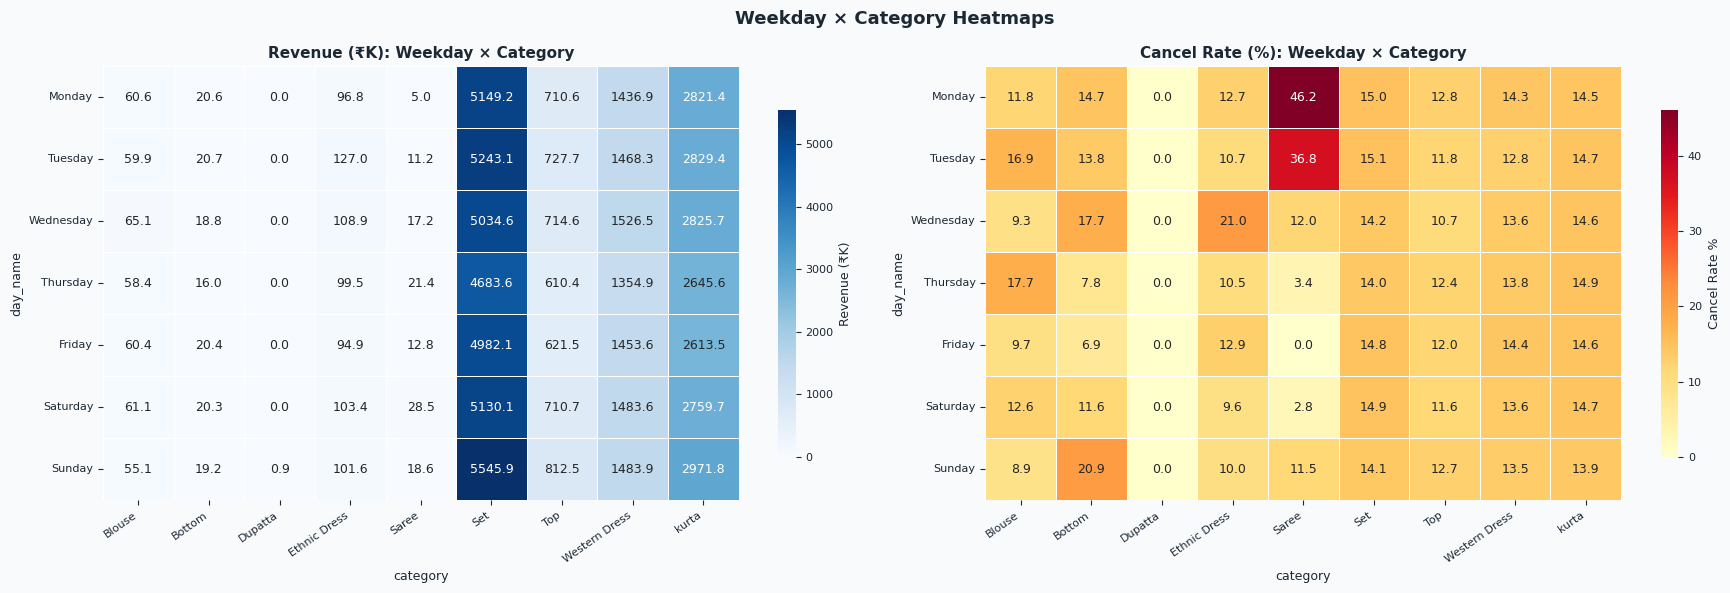

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Weekday × Category Heatmaps", fontweight='bold', fontsize=13)

sns.heatmap(wdc / 1000, ax=axes[0], cmap='Blues', annot=True, fmt='.1f',
            linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'label': 'Revenue (₹K)', 'shrink': 0.8})
axes[0].set_title("Revenue (₹K): Weekday × Category", fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

sns.heatmap(wdc_cancel, ax=axes[1], cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'label': 'Cancel Rate %', 'shrink': 0.8})
axes[1].set_title("Cancel Rate (%): Weekday × Category", fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

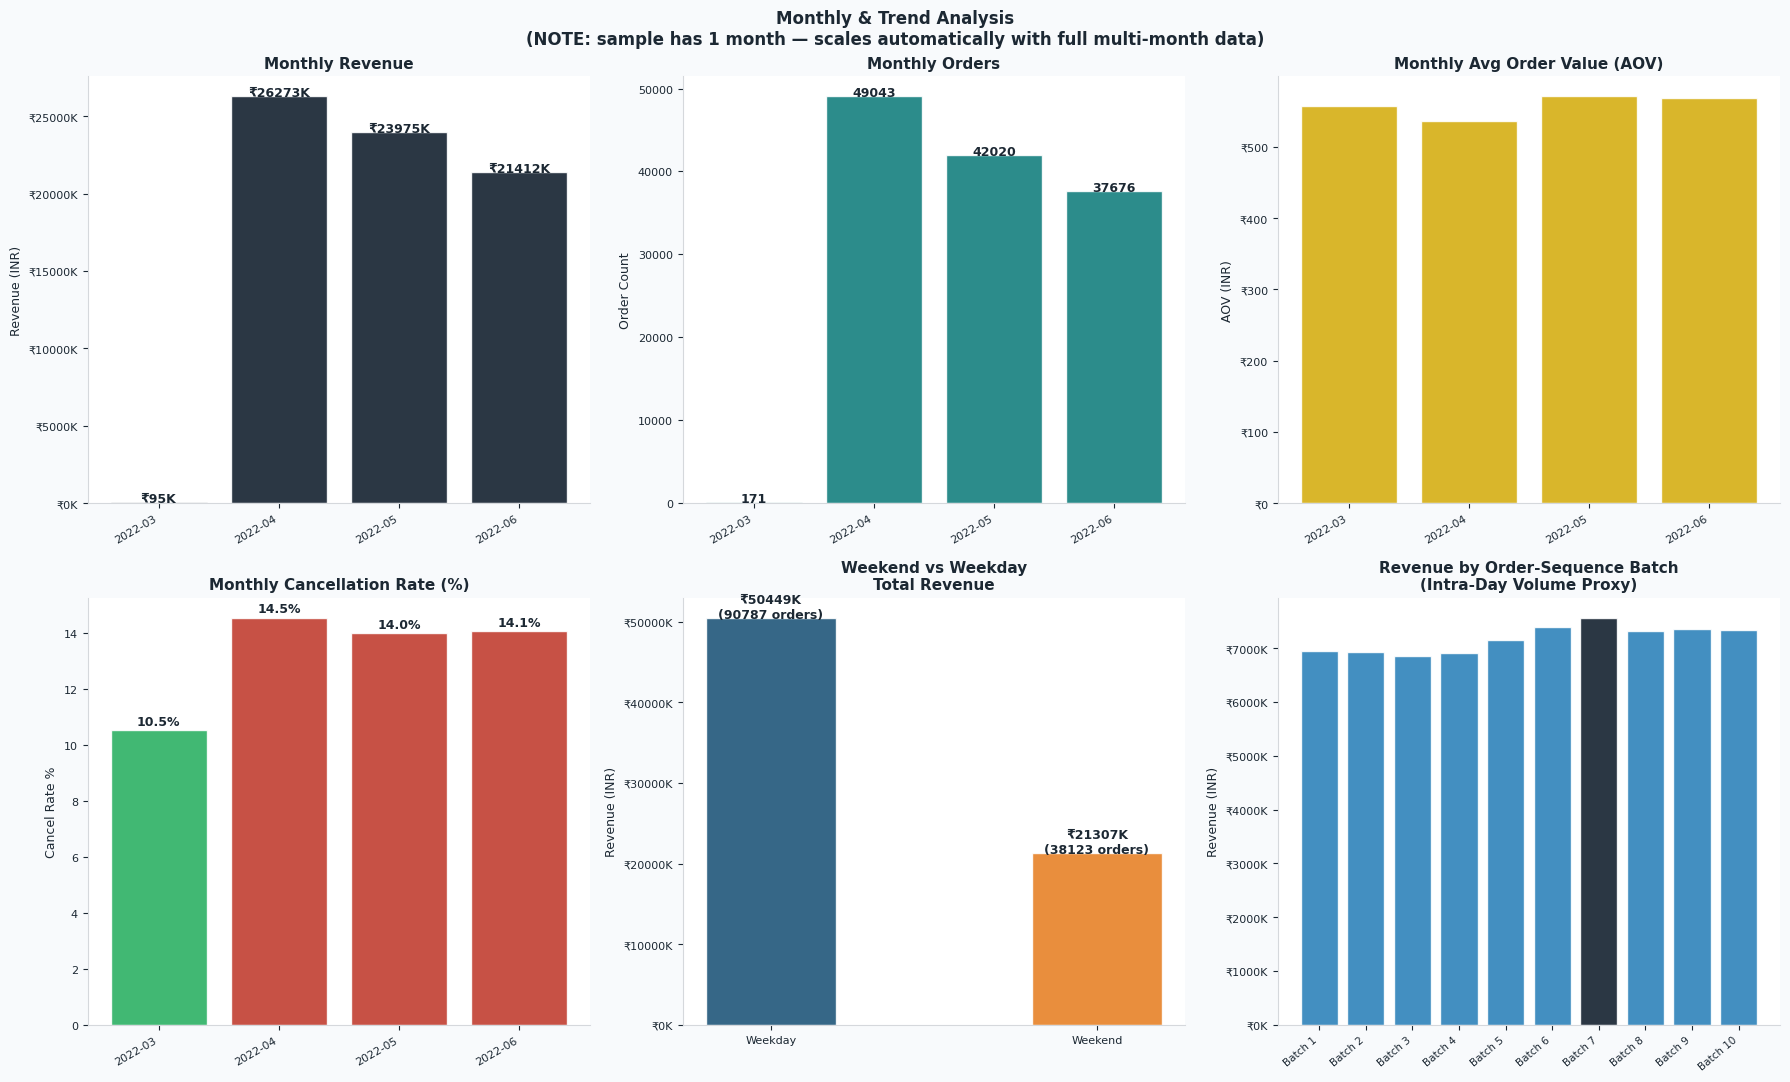

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Monthly & Trend Analysis\n"
             "(NOTE: sample has 1 month — scales automatically with full multi-month data)",
             fontweight='bold', fontsize=12)

month_labels = monthly['month_year'].tolist()

# a) Monthly revenue bar
ax = axes[0, 0]
ax.bar(month_labels, monthly['revenue'],
       color=P['navy'], edgecolor='white', alpha=0.88)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
ax.set_title("Monthly Revenue", fontweight='bold')
ax.set_ylabel("Revenue (INR)")
ax.set_xticklabels(month_labels, rotation=30, ha='right')
for i, v in enumerate(monthly['revenue']):
    ax.text(i, v+1000, f"₹{v/1000:.0f}K", ha='center', fontsize=9, fontweight='bold')

# b) Monthly orders
ax = axes[0, 1]
ax.bar(month_labels, monthly['orders'], color=P['teal'], edgecolor='white', alpha=0.88)
ax.set_title("Monthly Orders", fontweight='bold')
ax.set_ylabel("Order Count")
ax.set_xticklabels(month_labels, rotation=30, ha='right')
for i, v in enumerate(monthly['orders']):
    ax.text(i, v+5, str(int(v)), ha='center', fontsize=9, fontweight='bold')

# c) Monthly AOV
ax = axes[0, 2]
ax.bar(month_labels, monthly['aov'], color=P['gold'], edgecolor='white', alpha=0.88)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v:.0f}'))
ax.set_title("Monthly Avg Order Value (AOV)", fontweight='bold')
ax.set_ylabel("AOV (INR)")
ax.set_xticklabels(month_labels, rotation=30, ha='right')

# d) Monthly cancel rate
ax = axes[1, 0]
ax.bar(month_labels, monthly['cancel_rate_%'],
       color=[P['red'] if v > monthly['cancel_rate_%'].mean() else P['lime']
              for v in monthly['cancel_rate_%']],
       edgecolor='white', alpha=0.88)
ax.set_title("Monthly Cancellation Rate (%)", fontweight='bold')
ax.set_ylabel("Cancel Rate %")
ax.set_xticklabels(month_labels, rotation=30, ha='right')
for i, v in enumerate(monthly['cancel_rate_%']):
    ax.text(i, v+0.2, f"{v:.1f}%", ha='center', fontsize=9, fontweight='bold')

# e) Weekend vs Weekday revenue comparison
ax = axes[1, 1]
ww_labels = ['Weekday','Weekend']
ww_rev    = [wkdy['amount'].sum(), wknd['amount'].sum()]
ww_orders = [len(wkdy), len(wknd)]
bars_ww = ax.bar(ww_labels, ww_rev,
                 color=[P['blue'], P['amber']], edgecolor='white', alpha=0.88, width=0.4)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
ax.set_title("Weekend vs Weekday\nTotal Revenue", fontweight='bold')
ax.set_ylabel("Revenue (INR)")
for i, (v, o) in enumerate(zip(ww_rev, ww_orders)):
    ax.text(i, v+1000, f"₹{v/1000:.0f}K\n({o} orders)", ha='center',
            fontsize=9, fontweight='bold')

# f) Order sequence batches (intra-day proxy)
ax = axes[1, 2]
ax.bar(batch_stats['batch'].astype(str), batch_stats['revenue'],
       color=[P['navy'] if v == batch_stats['revenue'].max() else P['sky']
              for v in batch_stats['revenue']],
       edgecolor='white', alpha=0.88)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1000:.0f}K'))
ax.set_title("Revenue by Order-Sequence Batch\n(Intra-Day Volume Proxy)", fontweight='bold')
ax.set_ylabel("Revenue (INR)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7.5)

plt.tight_layout()
plt.show()



### Cancellation Analysis

In [ ]:
df['date']       = pd.to_datetime(df['date'], format='%m-%d-%y')
df['Month_Year'] = df['date'].dt.to_period('M').astype(str)
df['Month_Num']  = df['date'].dt.month
df['Year']       = df['date'].dt.year
df['Month_Name'] = df['date'].dt.strftime('%b %Y')

# Flags
df['is_cancelled'] = (df['status'] == 'Cancelled').astype(int)
df['is_delivered'] = (df['status'] == 'Shipped - Delivered to Buyer').astype(int)
df['is_returned']  = df['status'].str.contains('Return|Rejected', na=False).astype(int)
df['is_shipped']   = (df['status'] == 'Shipped').astype(int)


In [ ]:
monthly = (df.groupby(['Month_Year', 'Month_Name', 'Year', 'Month_Num'])
             .agg(
                 total_orders        = ('order_id',      'count'),
                 cancelled           = ('is_cancelled',  'sum'),
                 delivered           = ('is_delivered',  'sum'),
                 returned            = ('is_returned',   'sum'),
                 shipped             = ('is_shipped',    'sum'),
                 total_revenue       = ('amount',        'sum'),
                 cancelled_revenue   = ('amount',        lambda x: x[df.loc[x.index,'is_cancelled']==1].sum()),
                 avg_order_value     = ('amount',        'mean'),
             )
             .reset_index()
             .sort_values(['Year','Month_Num']))

monthly['cancel_rate_%']   = (monthly['cancelled']  / monthly['total_orders'] * 100).round(2)
monthly['deliver_rate_%']  = (monthly['delivered']  / monthly['total_orders'] * 100).round(2)
monthly['return_rate_%']   = (monthly['returned']   / monthly['total_orders'] * 100).round(2)
monthly['shipped_rate_%']  = (monthly['shipped']    / monthly['total_orders'] * 100).round(2)
monthly['mom_cancel_chg']  = monthly['cancel_rate_%'].diff()
monthly['mom_order_chg_%'] = monthly['total_orders'].pct_change() * 100

In [ ]:
cat_monthly = (df.groupby(['Month_Year','category'])
               .agg(total=('order_id','count'), cancelled=('is_cancelled','sum'))
               .reset_index())
cat_monthly['cancel_rate_%'] = (cat_monthly['cancelled'] / cat_monthly['total'] * 100).round(2)

In [ ]:
size_monthly = (df.groupby(['Month_Year','size'])
                .agg(total=('order_id','count'), cancelled=('is_cancelled','sum'))
                .reset_index())
size_monthly['cancel_rate_%'] = (size_monthly['cancelled'] / size_monthly['total'] * 100).round(2)

In [ ]:
ful_monthly = (df.groupby(['Month_Year','fulfilment'])
               .agg(total=('order_id','count'), cancelled=('is_cancelled','sum'))
               .reset_index())
ful_monthly['cancel_rate_%'] = (ful_monthly['cancelled'] / ful_monthly['total'] * 100).round(2)

In [ ]:
sub("MONTHLY CANCELLATION TREND")
print(f"\n  {'Month':<12}  {'Total':>7}  {'Cancelled':>10}  {'Cancel%':>9}  "
      f"{'Deliver%':>10}  {'Return%':>9}  {'MoM Δ Cancel%':>15}")
print("  " + "─"*78)
for _, r in monthly.iterrows():
    mom_str = (f"{r['mom_cancel_chg']:>+8.2f}pp"
               if pd.notna(r['mom_cancel_chg']) else "        —")
    trend = ("📈 Worse" if pd.notna(r['mom_cancel_chg']) and r['mom_cancel_chg'] > 0
             else "📉 Better" if pd.notna(r['mom_cancel_chg']) and r['mom_cancel_chg'] < 0
             else "  —  ")
    print(f"  {r['Month_Year']:<12}  {int(r['total_orders']):>7}  "
          f"{int(r['cancelled']):>10}  {r['cancel_rate_%']:>8.2f}%  "
          f"{r['deliver_rate_%']:>9.2f}%  {r['return_rate_%']:>8.2f}%  "
          f"{mom_str:>15}  {trend}")


  ┌── MONTHLY CANCELLATION TREND
  │

  Month           Total   Cancelled    Cancel%    Deliver%    Return%    MoM Δ Cancel%
  ──────────────────────────────────────────────────────────────────────────────
  2022-03           171          18     10.53%       9.36%      0.58%                —    —  
  2022-04         49043        7133     14.54%      24.64%      1.84%          +4.01pp  📈 Worse
  2022-05         42020        5879     13.99%      24.74%      1.71%          -0.55pp  📉 Better
  2022-06         37676        5301     14.07%      16.63%      1.29%          +0.08pp  📈 Worse


In [ ]:
sub("KEY CANCELLATION KPIs")
row("Total Orders",               f"{monthly['total_orders'].sum():,}")
row("Total Cancelled",            f"{monthly['cancelled'].sum():,}")
row("Overall Cancel Rate",        f"{monthly['cancelled'].sum()/monthly['total_orders'].sum()*100:.2f}%")
row("Overall Delivery Rate",      f"{monthly['delivered'].sum()/monthly['total_orders'].sum()*100:.2f}%")
row("Overall Return Rate",        f"{monthly['returned'].sum()/monthly['total_orders'].sum()*100:.2f}%")
if len(monthly) > 1:
    best  = monthly.loc[monthly['cancel_rate_%'].idxmin()]
    worst = monthly.loc[monthly['cancel_rate_%'].idxmax()]
    row("Best Month (lowest cancel)", f"{best['Month_Year']}  ({best['cancel_rate_%']:.2f}%)")
    row("Worst Month (highest cancel)",f"{worst['Month_Year']}  ({worst['cancel_rate_%']:.2f}%)")
    row("Peak-to-Trough Range",       f"{monthly['cancel_rate_%'].max() - monthly['cancel_rate_%'].min():.2f}pp")



  ┌── KEY CANCELLATION KPIs
  │
  │      Total Orders                               128,910
  │      Total Cancelled                            18,331
  │      Overall Cancel Rate                        14.22%
  │      Overall Delivery Rate                      22.31%
  │      Overall Return Rate                        1.63%
  │      Best Month (lowest cancel)                 2022-03  (10.53%)
  │      Worst Month (highest cancel)               2022-04  (14.54%)
  │      Peak-to-Trough Range                       4.01pp


In [ ]:
sub("CANCELLATION RATE BY CATEGORY (Per Month)")
for month in monthly['Month_Year']:
    print(f"\n  Month: {month}")
    cm = cat_monthly[cat_monthly['Month_Year']==month].sort_values('cancel_rate_%', ascending=False)
    print(f"  {'Category':<18}  {'Total':>7}  {'Cancelled':>10}  {'Cancel%':>9}")
    print("  " + "─"*50)
    for _, r in cm.iterrows():
        bar = '█' * int(r['cancel_rate_%'] / 2)
        flag = "  ⚠ HIGH" if r['cancel_rate_%'] > 20 else ""
        print(f"  {r['category']:<18}  {int(r['total']):>7}  {int(r['cancelled']):>10}  "
              f"{r['cancel_rate_%']:>8.2f}%  {bar}{flag}")


  ┌── CANCELLATION RATE BY CATEGORY (Per Month)
  │

  Month: 2022-03
  Category              Total   Cancelled    Cancel%
  ──────────────────────────────────────────────────
  Ethnic Dress              1           1    100.00%  ██████████████████████████████████████████████████  ⚠ HIGH
  Western Dress             9           3     33.33%  ████████████████  ⚠ HIGH
  Set                      75          10     13.33%  ██████
  kurta                    76           4      5.26%  ██
  Blouse                    1           0      0.00%  
  Top                       9           0      0.00%  

  Month: 2022-04
  Category              Total   Cancelled    Cancel%
  ──────────────────────────────────────────────────
  kurta                 19732        3002     15.21%  ███████
  Set                   20196        2977     14.74%  ███████
  Blouse                  418          57     13.64%  ██████
  Ethnic Dress            351          47     13.39%  ██████
  Saree                    75    

In [ ]:
sub("CANCELLATION RATE BY SIZE (Per Month)")
SIZE_ORDER = ['XS','S','M','L','XL','XXL','3XL','4XL','5XL','6XL','Free']
for month in monthly['Month_Year']:
    print(f"\n  Month: {month}")
    sm = (size_monthly[size_monthly['Month_Year']==month]
          .set_index('size').reindex(
              [s for s in SIZE_ORDER if s in size_monthly['size'].values])
          .reset_index())
    print(f"  {'Size':<8}  {'Total':>7}  {'Cancelled':>10}  {'Cancel%':>9}")
    print("  " + "─"*40)
    for _, r in sm.dropna().iterrows():
        flag = "  ⚠" if r['cancel_rate_%'] > 18 else ""
        print(f"  {r['size']:<8}  {int(r['total']):>7}  {int(r['cancelled']):>10}  "
              f"{r['cancel_rate_%']:>8.2f}%{flag}")


  ┌── CANCELLATION RATE BY SIZE (Per Month)
  │

  Month: 2022-03
  Size        Total   Cancelled    Cancel%
  ────────────────────────────────────────
  XS             11           0      0.00%
  S              20           2     10.00%
  M              30           2      6.67%
  L              37          11     29.73%  ⚠
  XL             26           0      0.00%
  XXL            27           1      3.70%
  3XL            16           1      6.25%
  5XL             2           1     50.00%  ⚠
  6XL             2           0      0.00%

  Month: 2022-04
  Size        Total   Cancelled    Cancel%
  ────────────────────────────────────────
  XS           4404         771     17.51%
  S            6708        1009     15.04%
  M            8595        1299     15.11%
  L            8623        1185     13.74%
  XL           7875        1144     14.53%
  XXL          6688         938     14.03%
  3XL          5641         725     12.85%
  4XL            91           6      6.59%
  5XL 

In [ ]:
sub("CANCELLATION RATE BY FULFILLMENT (Per Month)")
for month in monthly['Month_Year']:
    print(f"\n  Month: {month}")
    fm = ful_monthly[ful_monthly['Month_Year']==month].sort_values('cancel_rate_%', ascending=False)
    for _, r in fm.iterrows():
        print(f"  {r['fulfilment']:<12}  total={int(r['total']):>5}  "
              f"cancelled={int(r['cancelled']):>4}  cancel_rate={r['cancel_rate_%']:.2f}%")


  ┌── CANCELLATION RATE BY FULFILLMENT (Per Month)
  │

  Month: 2022-03
  Merchant      total=   23  cancelled=   6  cancel_rate=26.09%
  Amazon        total=  148  cancelled=  12  cancel_rate=8.11%

  Month: 2022-04
  Merchant      total=15789  cancelled=2806  cancel_rate=17.77%
  Amazon        total=33254  cancelled=4327  cancel_rate=13.01%

  Month: 2022-05
  Merchant      total=13419  cancelled=2295  cancel_rate=17.10%
  Amazon        total=28601  cancelled=3584  cancel_rate=12.53%

  Month: 2022-06
  Merchant      total=10026  cancelled=1752  cancel_rate=17.47%
  Amazon        total=27650  cancelled=3549  cancel_rate=12.84%


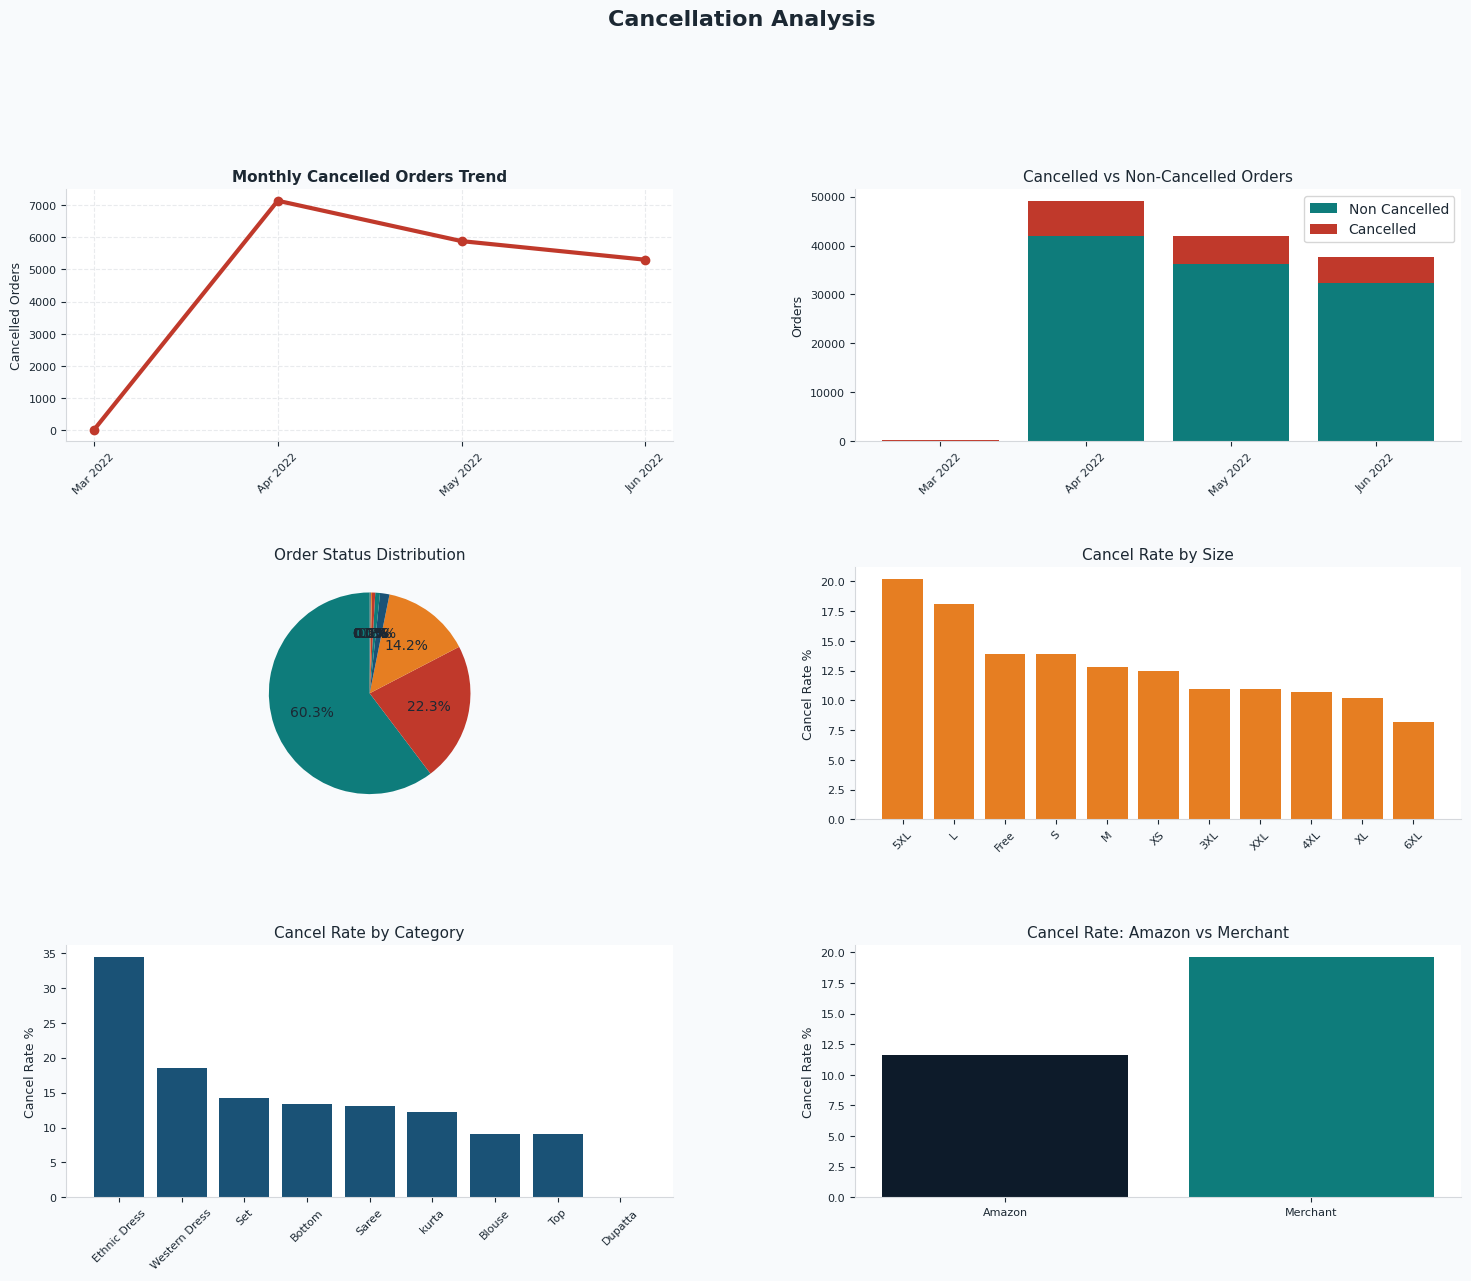

In [ ]:
C = dict(navy='#0D1B2A', blue='#1A5276', sky='#2980B9', teal='#0E7C7B',
         red='#C0392B', amber='#E67E22', gold='#D4AC0D', lime='#27AE60',
         purple='#6C3483', gray='#717D7E', bg='#F8FAFC', card='#FFFFFF',
         grid='#D5D8DC', text='#1C2833')

plt.rcParams.update({
    'figure.facecolor': C['bg'],
    'axes.facecolor': C['card'],
    'axes.edgecolor': C['grid'],
    'axes.labelcolor': C['text'],
    'xtick.color': C['text'],
    'ytick.color': C['text'],
    'grid.linestyle': '--',
    'grid.alpha': 0.5
})

months = monthly['Month_Year']
labels = monthly['Month_Name']
x = range(len(months))

fig = plt.figure(figsize=(18,18))
gs = gridspec.GridSpec(4,2,figure=fig,hspace=0.5,wspace=0.3)

fig.suptitle("Cancellation Analysis",fontsize=16,fontweight='bold')

# ── Chart 1 Monthly Cancelled Orders Trend ──
ax = fig.add_subplot(gs[0,0])

ax.plot(x, monthly['cancelled'], marker='o', lw=3, color=C['red'])

ax.set_title("Monthly Cancelled Orders Trend",fontweight='bold')
ax.set_ylabel("Cancelled Orders")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)

ax.grid(True)

# ── Chart 2 Cancelled vs Non Cancelled ──
ax = fig.add_subplot(gs[0,1])

cancelled = monthly['cancelled']
non_cancelled = monthly['total_orders'] - cancelled

ax.bar(x, non_cancelled, color=C['teal'], label='Non Cancelled')
ax.bar(x, cancelled, bottom=non_cancelled, color=C['red'], label='Cancelled')

ax.set_title("Cancelled vs Non-Cancelled Orders")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel("Orders")

ax.legend()

# ── Chart 3 Order Status Distribution ──
ax = fig.add_subplot(gs[1,0])

status_counts = df['status'].value_counts()

ax.pie(status_counts,
       autopct='%1.1f%%',
       startangle=90,
       colors=[C['teal'],C['red'],C['amber'],C['blue']])

ax.set_title("Order Status Distribution")

# ── Chart 4 Cancel Rate by Size ──
ax = fig.add_subplot(gs[1,1])

size_data = (
    size_monthly.groupby('size')['cancel_rate_%']
    .mean()
    .sort_values(ascending=False)
)

ax.bar(size_data.index, size_data.values, color=C['amber'])

ax.set_title("Cancel Rate by Size")
ax.set_ylabel("Cancel Rate %")
ax.tick_params(axis='x', rotation=45)

# ── Chart 5 Category Cancel Rate ──
ax = fig.add_subplot(gs[2,0])

cat_data = (
    cat_monthly.groupby('category')['cancel_rate_%']
    .mean()
    .sort_values(ascending=False)
)

ax.bar(cat_data.index, cat_data.values, color=C['blue'])

ax.set_title("Cancel Rate by Category")
ax.set_ylabel("Cancel Rate %")
ax.tick_params(axis='x', rotation=45)

# ── Chart 6 Fulfilment Cancel Rate ──
ax = fig.add_subplot(gs[2,1])

ful_data = (
    ful_monthly.groupby('fulfilment')['cancel_rate_%']
    .mean()
)

ax.bar(ful_data.index, ful_data.values,
       color=[C['navy'],C['teal']])

ax.set_title("Cancel Rate: Amazon vs Merchant")
ax.set_ylabel("Cancel Rate %")

plt.tight_layout()
plt.show()

In [ ]:
monthly

,Month_Year,Month_Name,Year,Month_Num,total_orders,cancelled,delivered,returned,shipped,total_revenue,cancelled_revenue,avg_order_value,cancel_rate_%,deliver_rate_%,return_rate_%,shipped_rate_%,mom_cancel_chg,mom_order_chg_%
0,2022-03,Mar 2022,2022,3,171,18,16,1,136,95355.00,0.0,557.631579,10.53,9.36,0.58,79.53,NaN,NaN
1,2022-04,Apr 2022,2022,4,49043,7133,12086,900,28916,26272649.62,0.0,535.706413,14.54,24.64,1.84,58.96,4.01,28580.116959
2,2022-05,May 2022,2022,5,42020,5879,10396,719,25009,23975445.00,0.0,570.572228,13.99,24.74,1.71,59.52,-0.55,-14.320086
3,2022-06,Jun 2022,2022,6,37676,5301,6266,486,23687,21412223.00,0.0,568.325273,14.07,16.63,1.29,62.87,0.08,-10.337934


# Conclusion

The analysis of the e-commerce dataset provides valuable insights into the company’s operational performance, customer behavior, and product demand patterns. During the analyzed period, the company generated significant revenue and served customers across thousands of cities in India, demonstrating strong market reach and operational scale.

The findings indicate that the business performance is heavily concentrated in a few product categories, particularly Sets and Kurtas, which contribute the majority of total revenue. This highlights the importance of these categories as key drivers of the company’s sales performance. Additionally, customer purchasing behavior shows a preference for mid-to-premium priced products, especially within the ₹500 to ₹1000 price range, suggesting that customers prioritize value and product quality over extremely low prices.

From a customer perspective, the company primarily serves B2C customers, while the B2B segment, although smaller, shows higher average order values and more stable purchasing patterns. This indicates a potential opportunity for growth in the B2B market.

The analysis also identified certain operational challenges. The order cancellation rate is relatively high, which may lead to revenue loss and operational inefficiencies. At the same time, the return rate remains low, indicating that customers are generally satisfied with the products they receive. Geographic analysis shows that demand is particularly strong in major metropolitan cities, reflecting higher adoption of online shopping in urban regions.

Overall, the company demonstrates strong revenue potential and wide geographic coverage. However, addressing operational inefficiencies, diversifying product performance, and improving customer engagement strategies will be essential for achieving sustainable long-term growth.

# Recommendations

Based on the insights derived from the analysis, the following strategic recommendations are proposed to improve business performance and ensure sustainable growth:

### 1. Reduce Order Cancellation Rate

The company should focus on minimizing order cancellations by improving inventory management and order processing systems. Providing accurate stock availability, realistic delivery timelines, and proactive order confirmation notifications can help reduce cancellations and improve order completion rates.

### 2. Strengthen High-Performing Product Categories

Since Sets and Kurtas generate the majority of revenue, the company should prioritize these categories by expanding product variety, introducing new designs, and maintaining sufficient inventory levels. Focused marketing campaigns around these categories can further boost sales.

### 3. Optimize Pricing Strategy

The analysis shows strong customer demand for products priced between ₹500 and ₹1000. The company should expand its product offerings in this price range and develop promotional bundles or discounts that increase perceived value while maintaining profitability.

### 4. Promote High-Performing Products

Top-performing SKUs should be strategically promoted through online advertising, homepage placements, and seasonal promotions. Highlighting these best-selling products can improve conversion rates and drive higher sales volumes.

### 5. Expand the B2B Customer Segment

The B2B segment shows higher average order values and lower cancellation rates. The company should develop targeted strategies such as bulk purchase discounts, dedicated B2B sales channels, and partnerships with retailers or boutiques to expand this segment.

### 6. Improve Logistics and Fulfillment Efficiency

Efficient logistics play a crucial role in customer satisfaction. The company should optimize fulfillment processes, strengthen partnerships with reliable delivery providers, and improve last-mile delivery efficiency to ensure faster and more reliable shipping.

### 7. Implement Data-Driven Inventory Management

Using historical sales data and demand forecasting models can help the company maintain optimal inventory levels. This will reduce stockouts for high-demand products and prevent overstocking of low-performing items.